# Group 2 Exploration — People & Vehicles Involved

**Owner:** Ibrahim

Columns to cover: INVTYPE, INVAGE, INJURY, FATAL_NO, INITDIR, VEHTYPE, MANOEUVER, DRIVACT, DRIVCOND, PEDTYPE, PEDACT, PEDCOND, CYCLISTYPE, CYCACT, CYCCOND

## What to include for each column
- Description, data type, range/unique values
- % missing / blank
- Distribution (value counts or histogram)
- How it relates to `ACCLASS` (fatal vs. non-fatal) — crosstab or grouped means



| Feature        | Definition                                                                                                                                                                                                        |
| -------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **INVTYPE**    | **Involved Party Type.** Identifies the type of person or entity involved in the collision, such as Driver, Passenger, Pedestrian, Cyclist, Vehicle Owner, Motorcycle Driver, or Truck Driver.                    |
| **INVAGE**     | **Involved Party Age Group.** Indicates the age category of the person involved in the collision (e.g., 0–4, 5–9, 20–24, 35–39, 65–69).                                                                           |
| **INJURY**     | **Injury Severity.** Describes the level of injury sustained by the individual involved in the collision (e.g., None, Minor, Major, Fatal).                                                                       |
| **FATAL_NO**   | **Fatality Number.** A unique identifier assigned to each fatal victim in a collision. It is populated only when the collision resulted in a fatality.                                                            |
| **INITDIR**    | **Initial Direction of Travel.** Indicates the direction the vehicle or road user was travelling immediately before the collision (e.g., North, South, East, West).                                               |
| **VEHTYPE**    | **Vehicle Type.** Specifies the type of vehicle involved, such as Automobile, Truck, Bus, Motorcycle, Bicycle, Taxi, or Emergency Vehicle.                                                                        |
| **MANOEUVER**  | **Vehicle Manoeuvre.** Describes what the vehicle was doing immediately before the collision, such as going straight, turning left, turning right, reversing, stopping, or changing lanes.                        |
| **DRIVACT**    | **Driver Action.** Records the driver's action or behaviour leading up to the collision, such as following too closely, failing to yield, improper lane change, or other contributing actions.                    |
| **DRIVCOND**   | **Driver Condition.** Describes the physical or mental condition of the driver at the time of the collision, such as normal, fatigued, inattentive, impaired by alcohol, impaired by drugs, or medical condition. |
| **PEDTYPE**    | **Pedestrian Type.** Classifies the pedestrian involved in the collision, providing additional information about the pedestrian's role or category. This field is populated only when a pedestrian is involved.   |
| **PEDACT**     | **Pedestrian Action.** Describes what the pedestrian was doing immediately before the collision, such as crossing with the signal, crossing without the signal, walking on the roadway, or standing.              |
| **PEDCOND**    | **Pedestrian Condition.** Indicates the condition of the pedestrian at the time of the collision, such as normal, inattentive, impaired, or other relevant condition.                                             |
| **CYCLISTYPE** | **Cyclist Type.** Identifies the category of cyclist involved in the collision. This field is completed only for collisions involving cyclists.                                                                   |
| **CYCACT**     | **Cyclist Action.** Describes the cyclist's action immediately before the collision, such as riding straight, turning, or changing lanes.                                                                         |
| **CYCCOND**    | **Cyclist Condition.** Indicates the cyclist's condition at the time of the collision, such as normal, inattentive, impaired, or other relevant condition.                                                        |


Variables by category

Understanding the variables by category can help guide your analysis:

- Person-related
INVTYPE
INVAGE
INJURY
FATAL_NO
- Driver and vehicle-related
INITDIR
VEHTYPE
MANOEUVER
DRIVACT
DRIVCOND
- Pedestrian-related
PEDTYPE
PEDACT
PEDCOND
- Cyclist-related
CYCLISTYPE
CYCACT
CYCCOND


To better understand the dataset, the variables can be grouped according to the type of information they provide.

- Person Information
INVTYPE
INVAGE
INJURY
FATAL_NO

These variables describe the individuals involved in each collision, including their role, age group, injury severity, and whether they were a fatal victim.

- Vehicle and Driver Information
INITDIR
VEHTYPE
MANOEUVER
DRIVACT
DRIVCOND

These variables describe the vehicle involved, its movement before the collision, and the driver's actions and condition.

- Pedestrian Information
PEDTYPE
PEDACT
PEDCOND

These variables provide additional details for collisions involving pedestrians.

- Cyclist Information
CYCLISTYPE
CYCACT
CYCCOND

These variables provide additional details for collisions involving cyclists.

- Purpose of the Analysis

The objective of this analysis is to investigate how participant characteristics, vehicle information, driver behaviour, pedestrian behaviour, and cyclist behaviour are associated with collision severity (ACCLASS). For each feature, the following aspects will be examined:

Variable description
Data type
Missing values
Unique values or categories
Distribution of observations
Relationship with collision severity (ACCLASS)
Key insights and observations

This exploratory analysis will also serve as the foundation for developing machine learning models to predict whether a collision is Fatal or Non-Fatal.

In [2]:
import pandas as pd

df = pd.read_csv(
    "TOTAL_KSI_4115794401574937330.csv",
    encoding="utf-8-sig"
)

df.shape

(18957, 54)

In [3]:
# TODO: clean ACCLASS the same way as the other notebooks for consistency:
# df = df[df['ACCLASS'].notna() & (df['ACCLASS'].str.strip() != '')]
# df['FATAL'] = df['ACCLASS'].apply(lambda x: 1 if str(x).strip().lower() == 'fatal' else 0)

In [16]:
df['ACCLASS'].unique()

array(['Non-Fatal Injury', 'Fatal', 'Property Damage O', nan],
      dtype=object)

## TODO: column-by-column exploration

Add a cell (or a few) per column above.

In [4]:
df.head()

,OBJECTID,INDEX,ACCNUM,DATE,TIME,STREET1,STREET2,OFFSET,ROAD_CLASS,DISTRICT,...,REDLIGHT,ALCOHOL,DISABILITY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,DIVISION,x,y
0,1,3389067,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
1,2,3389068,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
2,3,3389069,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
3,4,3389070,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
4,5,3389071,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06


In [5]:
print(df.columns.tolist())

['OBJECTID', 'INDEX', 'ACCNUM', 'DATE', 'TIME', 'STREET1', 'STREET2', 'OFFSET', 'ROAD_CLASS', 'DISTRICT', 'LATITUDE', 'LONGITUDE', 'ACCLOC', 'TRAFFCTL', 'VISIBILITY', 'LIGHT', 'RDSFCOND', 'ACCLASS', 'IMPACTYPE', 'INVTYPE', 'INVAGE', 'INJURY', 'FATAL_NO', 'INITDIR', 'VEHTYPE', 'MANOEUVER', 'DRIVACT', 'DRIVCOND', 'PEDTYPE', 'PEDACT', 'PEDCOND', 'CYCLISTYPE', 'CYCACT', 'CYCCOND', 'PEDESTRIAN', 'CYCLIST', 'AUTOMOBILE', 'MOTORCYCLE', 'TRUCK', 'TRSN_CITY_VEH', 'EMERG_VEH', 'PASSENGER', 'SPEEDING', 'AG_DRIV', 'REDLIGHT', 'ALCOHOL', 'DISABILITY', 'HOOD_158', 'NEIGHBOURHOOD_158', 'HOOD_140', 'NEIGHBOURHOOD_140', 'DIVISION', 'x', 'y']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18957 entries, 0 to 18956
Data columns (total 54 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OBJECTID           18957 non-null  int64  
 1   INDEX              18957 non-null  int64  
 2   ACCNUM             14027 non-null  float64
 3   DATE               18957 non-null  object 
 4   TIME               18957 non-null  int64  
 5   STREET1            18957 non-null  object 
 6   STREET2            17251 non-null  object 
 7   OFFSET             3820 non-null   object 
 8   ROAD_CLASS         18471 non-null  object 
 9   DISTRICT           18728 non-null  object 
 10  LATITUDE           18957 non-null  float64
 11  LONGITUDE          18957 non-null  float64
 12  ACCLOC             13501 non-null  object 
 13  TRAFFCTL           18882 non-null  object 
 14  VISIBILITY         18933 non-null  object 
 15  LIGHT              18953 non-null  object 
 16  RDSFCOND           189

In [7]:
(df.isnull().sum().sort_values(ascending=False).to_frame(name="Missing Values"))

,Missing Values
EMERG_VEH,18908
DISABILITY,18464
CYCCOND,18157
CYCACT,18155
CYCLISTYPE,18152
ALCOHOL,18149
FATAL_NO,18087
TRSN_CITY_VEH,17809
TRUCK,17788
REDLIGHT,17380


## InvType

In [8]:
# Data type
print(df["INVTYPE"].dtype)

# Number of unique values
print(df["INVTYPE"].nunique())

# List the unique values
print(df["INVTYPE"].unique())

object
19
['Passenger' 'Driver' 'Vehicle Owner' 'Other Property Owner' 'Pedestrian'
 'Cyclist' 'Other' 'Motorcycle Driver' 'Truck Driver' 'In-Line Skater'
 'Driver - Not Hit' 'Motorcycle Passenger' nan 'Moped Driver' 'Wheelchair'
 'Pedestrian - Not Hit' 'Trailer Owner' 'Witness' 'Cyclist Passenger'
 'Moped Passenger']


In [9]:
df["INVTYPE"].value_counts(dropna=False)

INVTYPE
Driver                  8651
Pedestrian              3275
Passenger               2889
Vehicle Owner           1638
Cyclist                  822
Motorcycle Driver        745
Truck Driver             366
Other Property Owner     257
Other                    180
Motorcycle Passenger      41
Moped Driver              30
Wheelchair                17
Driver - Not Hit          17
NaN                       16
In-Line Skater             5
Cyclist Passenger          3
Trailer Owner              2
Pedestrian - Not Hit       1
Witness                    1
Moped Passenger            1
Name: count, dtype: int64

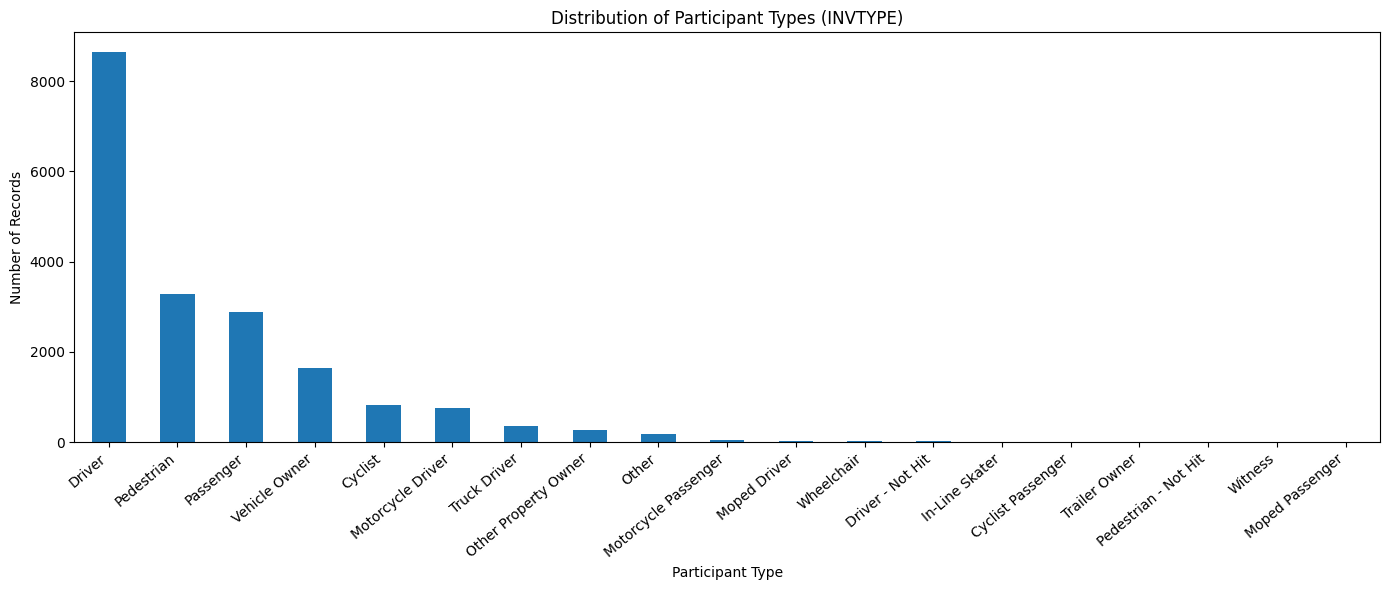

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

df["INVTYPE"].value_counts().plot(kind="bar")

plt.title("Distribution of Participant Types (INVTYPE)")
plt.xlabel("Participant Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=40, ha="right")

plt.tight_layout()
plt.show()

In [14]:
pd.crosstab(df["INVTYPE"], df["ACCLASS"])

ACCLASS,Fatal,Non-Fatal Injury,Property Damage O
INVTYPE,,,
Cyclist,45,777,0
Cyclist Passenger,0,3,0
Driver,1102,7538,10
Driver - Not Hit,3,14,0
In-Line Skater,0,5,0
Moped Driver,1,29,0
Moped Passenger,0,1,0
Motorcycle Driver,103,642,0
Motorcycle Passenger,4,37,0


In [17]:
df["ACCLASS"].value_counts(dropna=False)

ACCLASS
Non-Fatal Injury     16268
Fatal                 2670
Property Damage O       18
NaN                      1
Name: count, dtype: int64

In [18]:
pd.crosstab(
    df["INVTYPE"],
    df["ACCLASS"],
    normalize="index"
).round(3) * 100

ACCLASS,Fatal,Non-Fatal Injury,Property Damage O
INVTYPE,,,
Cyclist,5.5,94.5,0.0
Cyclist Passenger,0.0,100.0,0.0
Driver,12.7,87.1,0.1
Driver - Not Hit,17.6,82.4,0.0
In-Line Skater,0.0,100.0,0.0
Moped Driver,3.3,96.7,0.0
Moped Passenger,0.0,100.0,0.0
Motorcycle Driver,13.8,86.2,0.0
Motorcycle Passenger,9.8,90.2,0.0


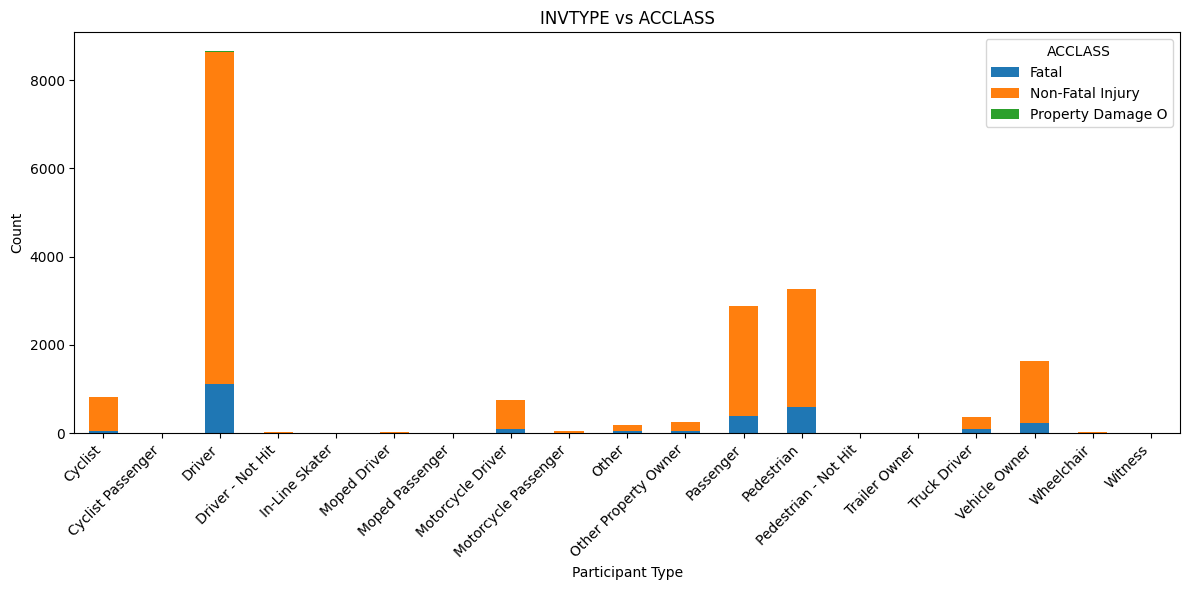

In [19]:
pd.crosstab(df["INVTYPE"], df["ACCLASS"]).plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("INVTYPE vs ACCLASS")
plt.xlabel("Participant Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Key Insights

- INVTYPE contains 19 participant categories and has only 16 missing values (0.08%), indicating excellent completeness.
- Drivers are the most common participants, followed by pedestrians and passengers.
- Pedestrians (18.2%) have a higher proportion of fatal collisions than drivers (12.7%) in this dataset.
- Categories such as Wheelchair and Witness show high fatal percentages, but these results should be interpreted cautiously due to very small sample sizes.
- Property Damage Only collisions are extremely rare across all participant types, supporting the decision to combine them with non-fatal cases for binary classification.

## Feature 2: INVAGE (Involved Party Age Group)

**Description:**  
The `INVAGE` variable represents the age group of the individual involved in the collision. It is a categorical variable that groups people into predefined age ranges rather than recording their exact age.

This feature is analyzed to determine which age groups are most frequently involved in collisions and whether collision severity differs across age groups.

In [20]:
# Data Type
print("Data Type:")
print(df["INVAGE"].dtype)

Data Type:
object


In [21]:
# Missing Values
missing = df["INVAGE"].isnull().sum()
missing_percent = (missing / len(df)) * 100

print(f"Missing Values: {missing}")
print(f"Missing Percentage: {missing_percent:.2f}%")

Missing Values: 0
Missing Percentage: 0.00%


In [22]:
print("Number of Unique Values:")
print(df["INVAGE"].nunique())

Number of Unique Values:
21


In [23]:
age_counts = df["INVAGE"].value_counts(dropna=False)

print(age_counts)

INVAGE
unknown     2625
20 to 24    1800
25 to 29    1723
30 to 34    1450
35 to 39    1382
50 to 54    1353
40 to 44    1314
45 to 49    1293
55 to 59    1156
60 to 64     925
15 to 19     883
65 to 69     723
70 to 74     560
75 to 79     456
80 to 84     351
10 to 14     260
85 to 89     224
5 to 9       206
0 to 4       190
90 to 94      68
Over 95       15
Name: count, dtype: int64


In [24]:
age_percentage = (
    df["INVAGE"]
    .value_counts(normalize=True, dropna=False)
    * 100
).round(2)

print(age_percentage)

INVAGE
unknown     13.85
20 to 24     9.50
25 to 29     9.09
30 to 34     7.65
35 to 39     7.29
50 to 54     7.14
40 to 44     6.93
45 to 49     6.82
55 to 59     6.10
60 to 64     4.88
15 to 19     4.66
65 to 69     3.81
70 to 74     2.95
75 to 79     2.41
80 to 84     1.85
10 to 14     1.37
85 to 89     1.18
5 to 9       1.09
0 to 4       1.00
90 to 94     0.36
Over 95      0.08
Name: proportion, dtype: float64


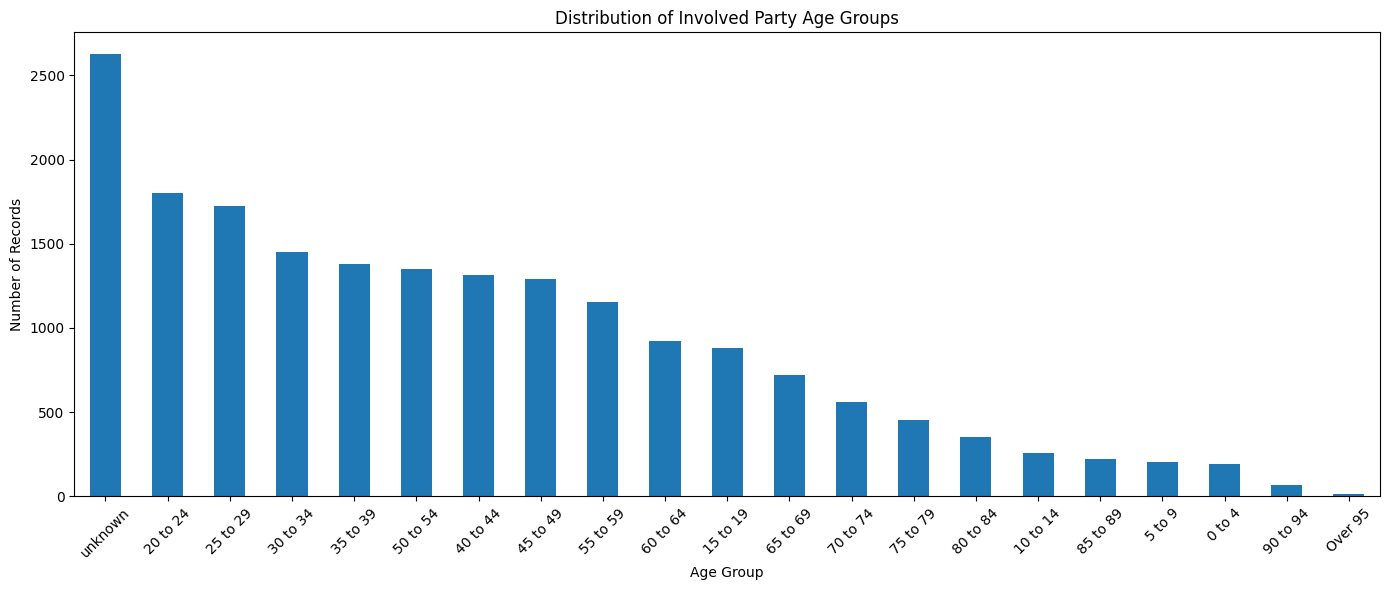

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

df["INVAGE"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Involved Party Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [26]:
age_accclass = pd.crosstab(
    df["INVAGE"],
    df["ACCLASS"]
)

print(age_accclass)

ACCLASS   Fatal  Non-Fatal Injury  Property Damage O
INVAGE                                              
0 to 4       16               174                  0
10 to 14     18               242                  0
15 to 19    130               752                  1
20 to 24    234              1563                  3
25 to 29    205              1516                  2
30 to 34    196              1254                  0
35 to 39    174              1206                  2
40 to 44    170              1142                  2
45 to 49    151              1138                  4
5 to 9       34               172                  0
50 to 54    171              1181                  1
55 to 59    170               985                  1
60 to 64    131               794                  0
65 to 69    116               607                  0
70 to 74     99               459                  1
75 to 79     94               362                  0
80 to 84     92               258             

In [27]:
age_percentage_table = (
    pd.crosstab(
        df["INVAGE"],
        df["ACCLASS"],
        normalize="index"
    )
    *100
).round(2)

print(age_percentage_table)

ACCLASS   Fatal  Non-Fatal Injury  Property Damage O
INVAGE                                              
0 to 4     8.42             91.58               0.00
10 to 14   6.92             93.08               0.00
15 to 19  14.72             85.16               0.11
20 to 24  13.00             86.83               0.17
25 to 29  11.90             87.99               0.12
30 to 34  13.52             86.48               0.00
35 to 39  12.59             87.26               0.14
40 to 44  12.94             86.91               0.15
45 to 49  11.68             88.01               0.31
5 to 9    16.50             83.50               0.00
50 to 54  12.64             87.29               0.07
55 to 59  14.71             85.21               0.09
60 to 64  14.16             85.84               0.00
65 to 69  16.04             83.96               0.00
70 to 74  17.71             82.11               0.18
75 to 79  20.61             79.39               0.00
80 to 84  26.21             73.50             

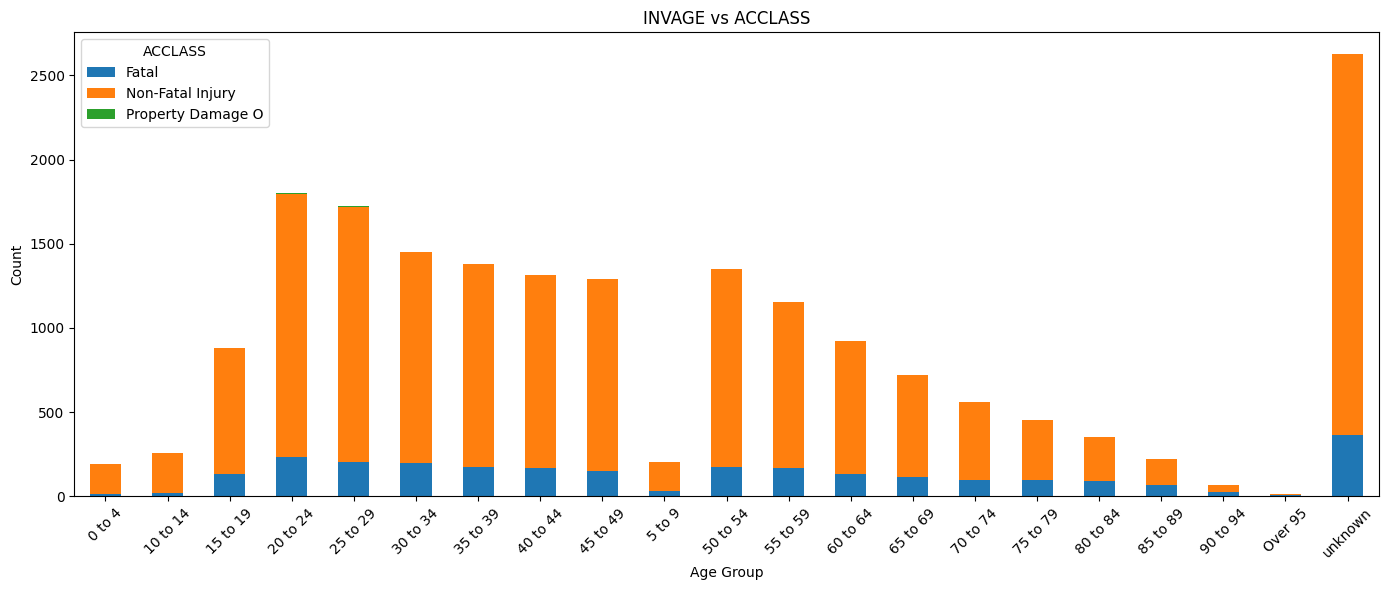

In [29]:
pd.crosstab(
    df["INVAGE"],
    df["ACCLASS"]
).plot(
    kind="bar",
    stacked=True,
    figsize=(14,6)
)

plt.title("INVAGE vs ACCLASS")

plt.xlabel("Age Group")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


FEATURE: INJURY

1. Data Type
object

2. Missing Values
Missing: 8897
Missing %: 46.93

3. Number of Unique Values
4

4. Unique Values
['Major' 'Minor' 'Fatal' 'Minimal']

5. Frequency Distribution
INJURY
NaN        8897
Major      6445
Minor      1479
Minimal    1160
Fatal       976
Name: count, dtype: int64

6. Percentage Distribution
INJURY
NaN        46.93
Major      34.00
Minor       7.80
Minimal     6.12
Fatal       5.15
Name: proportion, dtype: float64


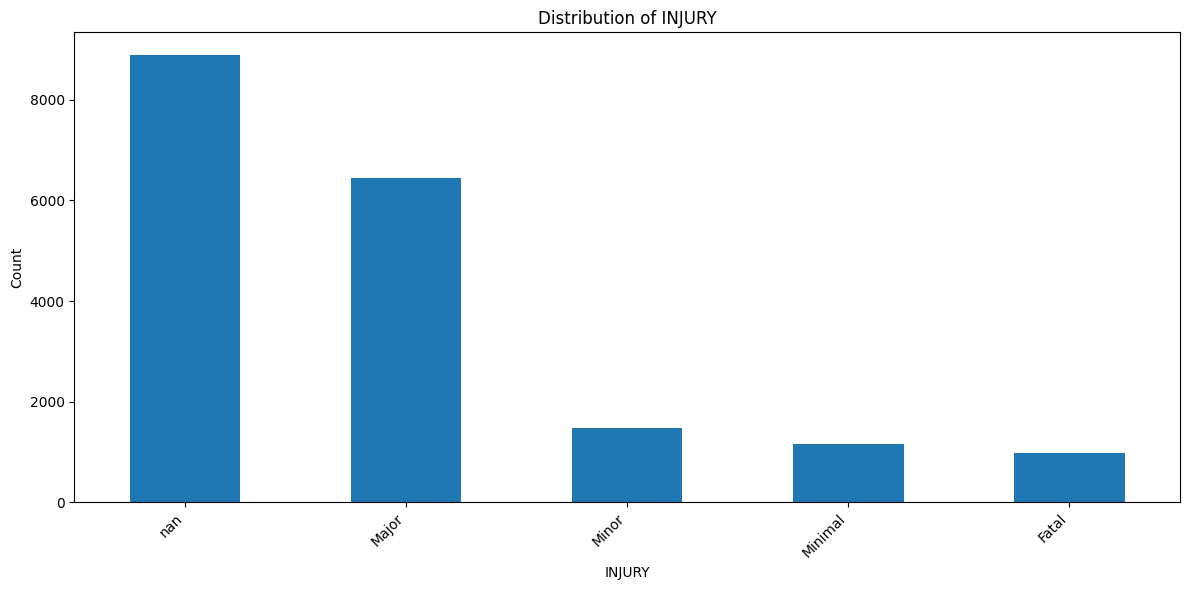


7. Crosstab with ACCLASS
ACCLASS  Fatal  Non-Fatal Injury  Property Damage O
INJURY                                             
Fatal      974                 1                  0
Major      121              6313                 11
Minimal    103              1057                  0
Minor      256              1223                  0

8. Percentage Crosstab
ACCLASS  Fatal  Non-Fatal Injury  Property Damage O
INJURY                                             
Fatal    99.90              0.10               0.00
Major     1.88             97.95               0.17
Minimal   8.88             91.12               0.00
Minor    17.31             82.69               0.00


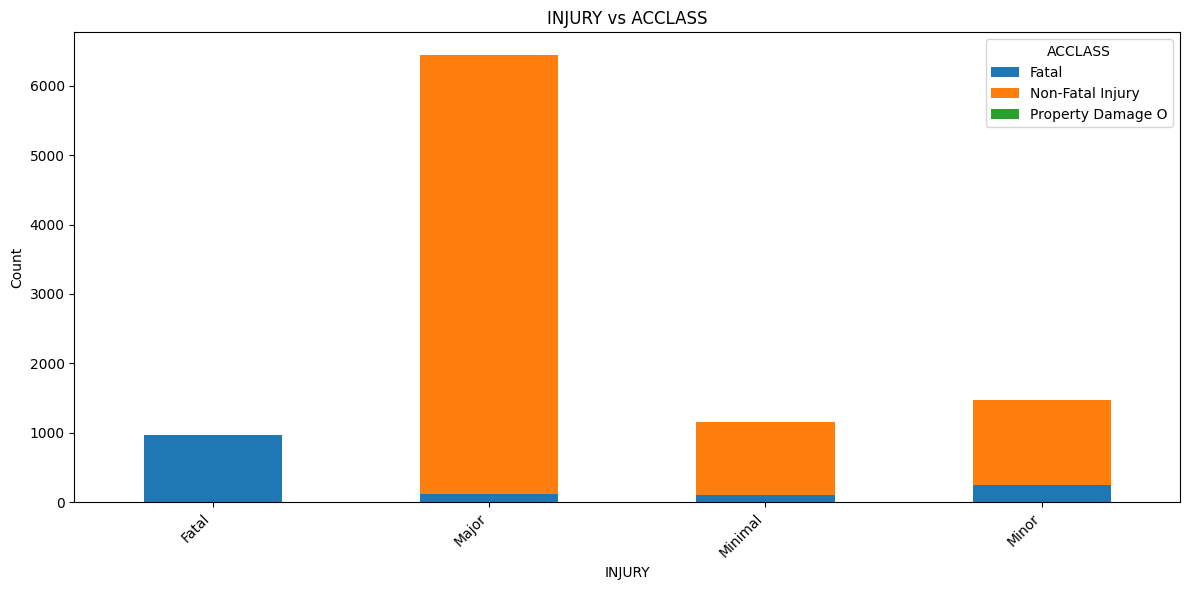

In [30]:
# ============================================================
# FEATURE: INJURY
# Description: Injury Severity
# ============================================================

feature = "INJURY"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


FEATURE: FATAL_NO

1. Data Type
float64

2. Missing Values
Missing: 18087
Missing %: 95.41

3. Number of Unique Values
78

4. Unique Values
[ 1.  2.  3.  4.  5.  6.  7.  8. 12. 10.  9. 11. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 26. 23. 24. 25. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 46. 45. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 57. 56. 58. 59. 60. 61. 62. 63. 65. 64. 78. 66. 67. 68. 69. 70. 71.
 72. 73. 74. 75. 76. 77.]

5. Frequency Distribution
FATAL_NO
NaN     18087
11.0       20
19.0       16
21.0       16
22.0       16
        ...  
70.0        1
69.0        1
68.0        1
78.0        1
77.0        1
Name: count, Length: 79, dtype: int64

6. Percentage Distribution
FATAL_NO
NaN     95.41
11.0     0.11
19.0     0.08
21.0     0.08
22.0     0.08
        ...  
70.0     0.01
69.0     0.01
68.0     0.01
78.0     0.01
77.0     0.01
Name: proportion, Length: 79, dtype: float64


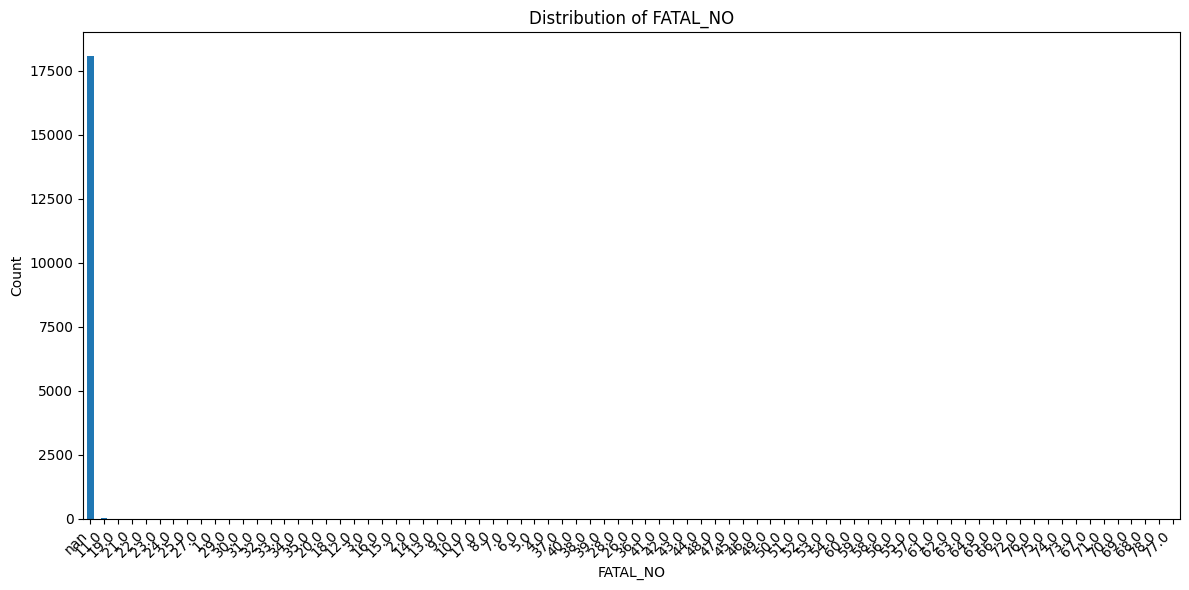


7. Crosstab with ACCLASS
ACCLASS   Fatal
FATAL_NO       
1.0          16
2.0          16
3.0          16
4.0          16
5.0          16
...         ...
74.0          1
75.0          1
76.0          1
77.0          1
78.0          1

[78 rows x 1 columns]

8. Percentage Crosstab
ACCLASS   Fatal
FATAL_NO       
1.0       100.0
2.0       100.0
3.0       100.0
4.0       100.0
5.0       100.0
...         ...
74.0      100.0
75.0      100.0
76.0      100.0
77.0      100.0
78.0      100.0

[78 rows x 1 columns]


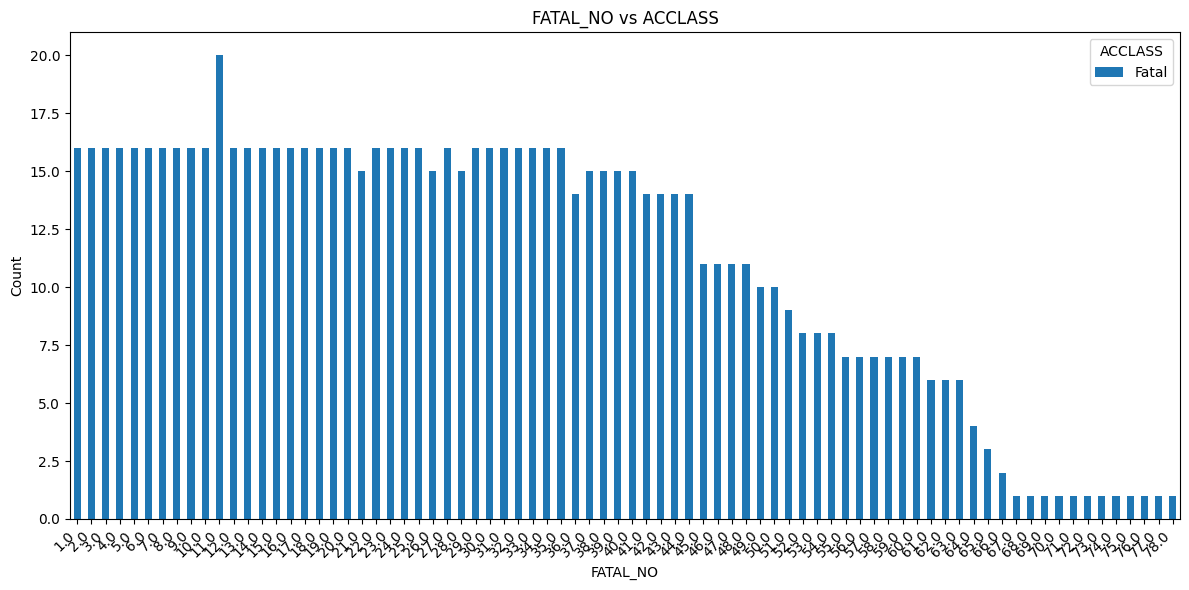

In [31]:
# ============================================================
# FEATURE: FATAL_NO
# Description: Fatality Number
# ============================================================

feature = "FATAL_NO"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



FEATURE: INITDIR

1. Data Type
object

2. Missing Values
Missing: 5277
Missing %: 27.84

3. Number of Unique Values
5

4. Unique Values
['North' 'South' 'East' 'West' 'Unknown']

5. Frequency Distribution
INITDIR
NaN        5277
East       3388
West       3339
South      3226
North      3201
Unknown     526
Name: count, dtype: int64

6. Percentage Distribution
INITDIR
NaN        27.84
East       17.87
West       17.61
South      17.02
North      16.89
Unknown     2.77
Name: proportion, dtype: float64


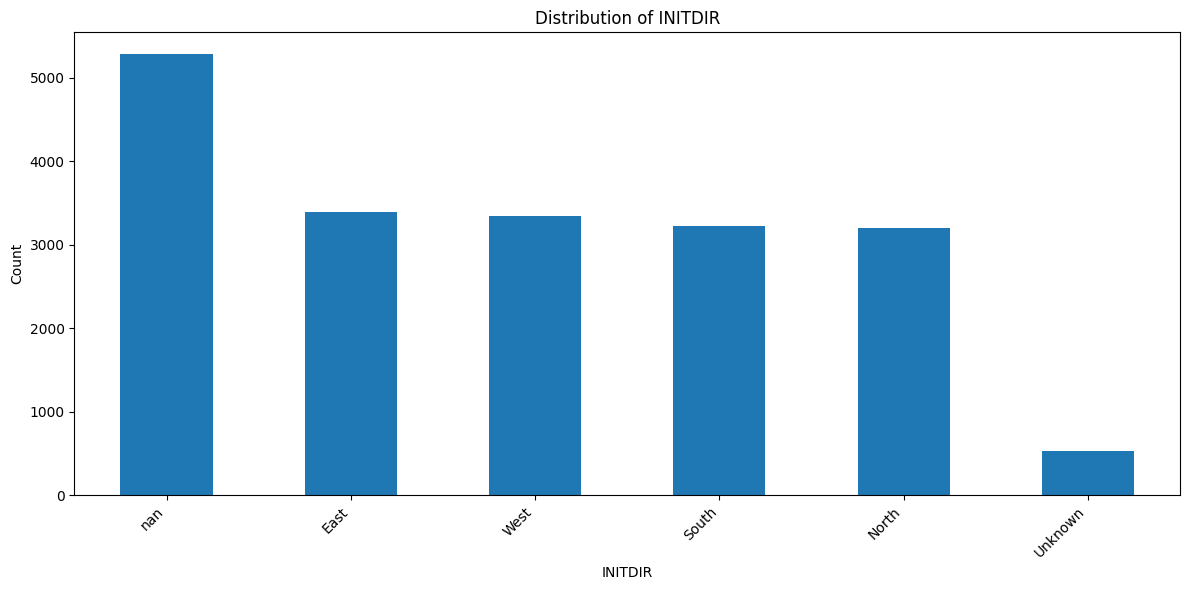


7. Crosstab with ACCLASS
ACCLASS  Fatal  Non-Fatal Injury  Property Damage O
INITDIR                                            
East       484              2900                  4
North      428              2772                  1
South      454              2768                  3
Unknown    106               419                  1
West       502              2833                  4

8. Percentage Crosstab
ACCLASS  Fatal  Non-Fatal Injury  Property Damage O
INITDIR                                            
East     14.29             85.60               0.12
North    13.37             86.60               0.03
South    14.08             85.83               0.09
Unknown  20.15             79.66               0.19
West     15.03             84.85               0.12


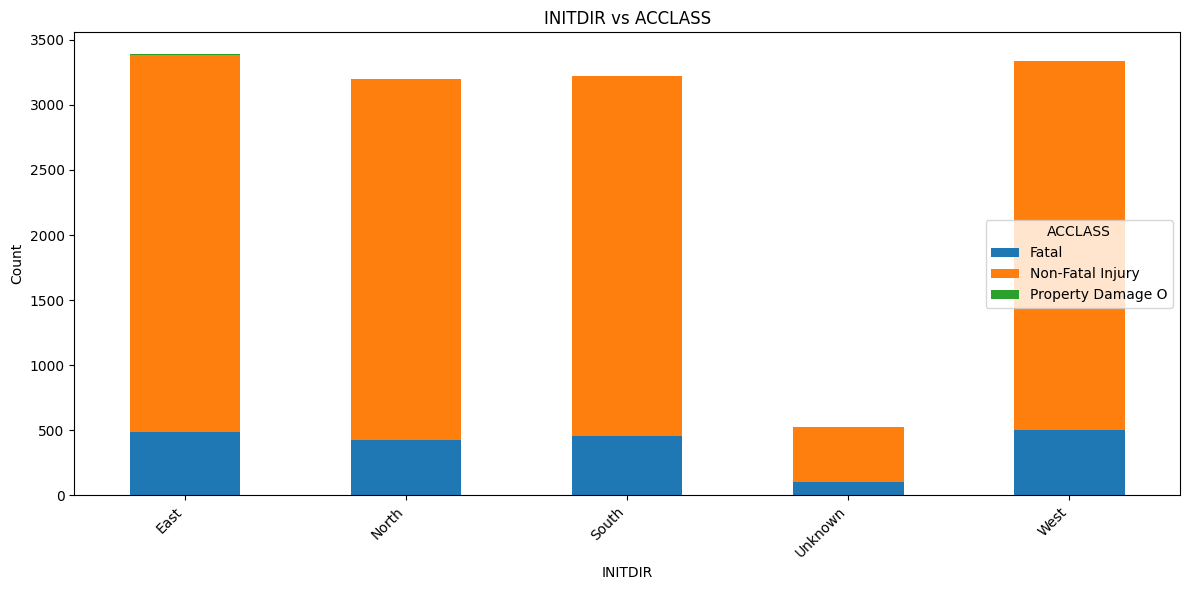

In [32]:
# ============================================================
# FEATURE: INITDIR
# Description: Initial Direction
# ============================================================

feature = "INITDIR"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



FEATURE: VEHTYPE

1. Data Type
object

2. Missing Values
Missing: 3487
Missing %: 18.39

3. Number of Unique Values
32

4. Unique Values
['Automobile, Station Wagon' 'Other' 'Passenger Van'
 'Municipal Transit Bus (TTC)' 'Taxi' 'Bicycle' 'Delivery Van'
 'Motorcycle' 'Truck - Open' 'Moped' 'Pick Up Truck' 'Tow Truck'
 'Police Vehicle' 'Truck-Tractor' 'Street Car'
 'Truck - Closed (Blazer, etc)' 'Truck - Dump'
 'Bus (Other) (Go Bus, Gray Coa' 'Construction Equipment' 'Intercity Bus'
 'Truck (other)' 'Fire Vehicle' 'School Bus' 'Other Emergency Vehicle'
 'Off Road - 2 Wheels' 'Truck - Tank' 'Truck - Car Carrier' 'Ambulance'
 'Off Road - 4 Wheels' 'Off Road - Other' 'Rickshaw' 'Unknown']

5. Frequency Distribution
VEHTYPE
Automobile, Station Wagon        7805
Other                            4753
NaN                              3487
Bicycle                           819
Motorcycle                        747
Municipal Transit Bus (TTC)       284
Pick Up Truck                     270
Truck

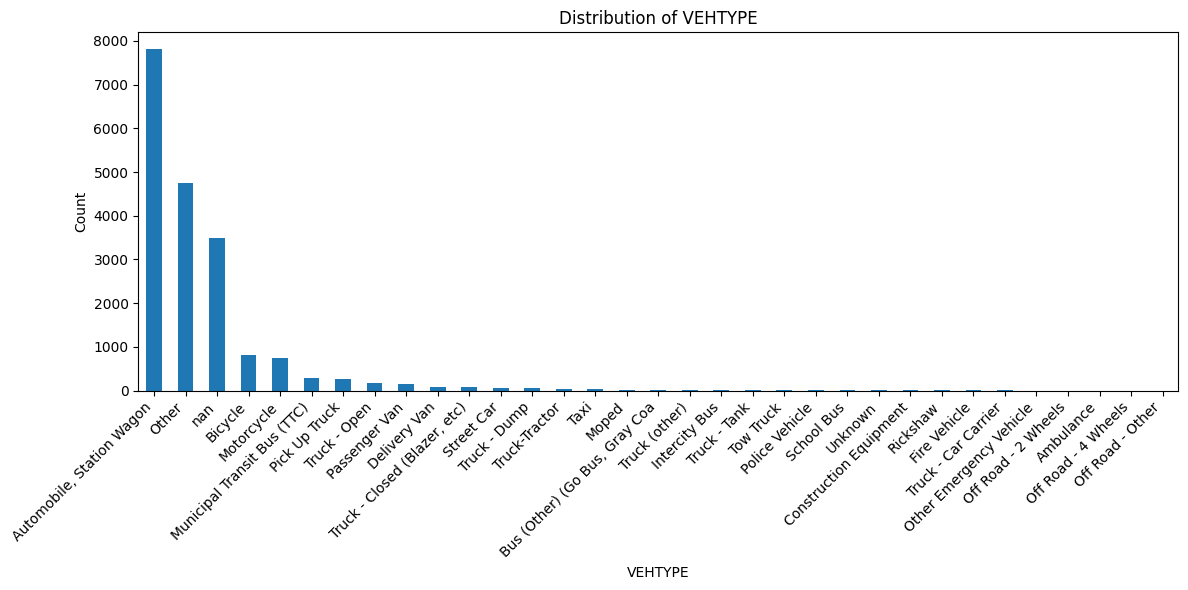


7. Crosstab with ACCLASS
ACCLASS                        Fatal  Non-Fatal Injury  Property Damage O
VEHTYPE                                                                  
Ambulance                          0                 1                  0
Automobile, Station Wagon        952              6845                  7
Bicycle                           46               773                  0
Bus (Other) (Go Bus, Gray Coa      2                17                  1
Construction Equipment             0                 4                  0
Delivery Van                      26                61                  0
Fire Vehicle                       0                 3                  0
Intercity Bus                      2                12                  0
Moped                              0                24                  0
Motorcycle                       103               644                  0
Municipal Transit Bus (TTC)       53               230                  1
Off Road - 2

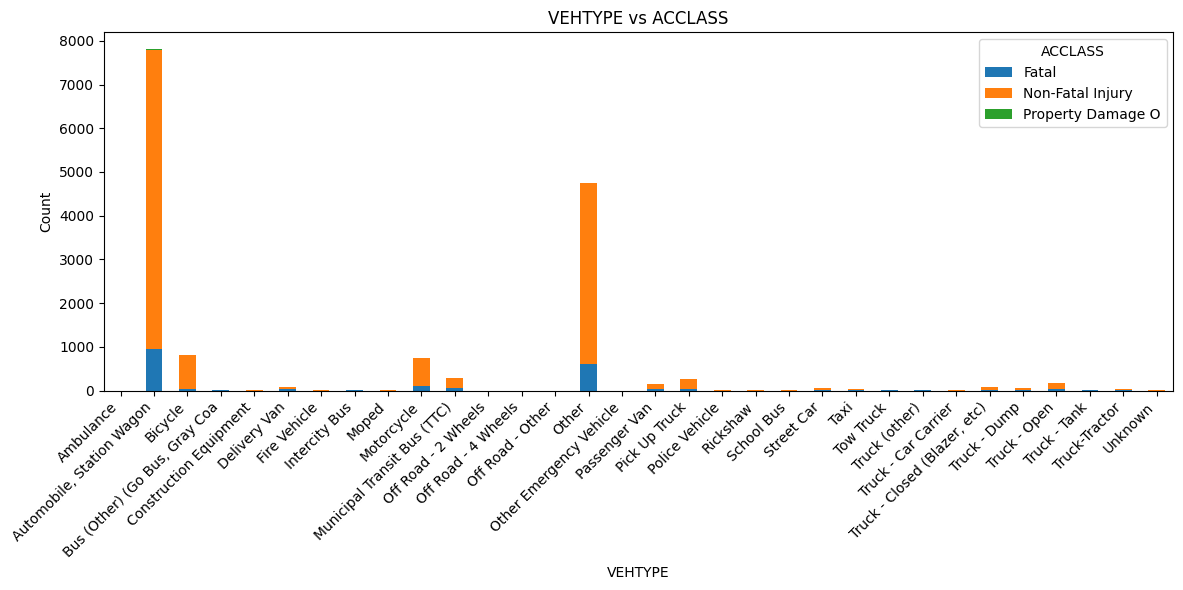

In [33]:
# ============================================================
# FEATURE: VEHTYPE
# Description: Vehicle Type
# ============================================================

feature = "VEHTYPE"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



FEATURE: MANOEUVER

1. Data Type
object

2. Missing Values
Missing: 7953
Missing %: 41.95

3. Number of Unique Values
16

4. Unique Values
['Going Ahead' 'Changing Lanes' 'Turning Right' 'Slowing or Stopping'
 'Turning Left' 'Other' 'Stopped' 'Unknown' 'Parked' 'Overtaking'
 'Making U Turn' 'Reversing' 'Pulling Away from Shoulder or Curb'
 'Pulling Onto Shoulder or towardCurb' 'Merging' 'Disabled']

5. Frequency Distribution
MANOEUVER
NaN                                    7953
Going Ahead                            6542
Turning Left                           1877
Stopped                                 634
Turning Right                           505
Slowing or Stopping                     294
Changing Lanes                          227
Other                                   186
Parked                                  185
Unknown                                 137
Reversing                               123
Making U Turn                           112
Overtaking                      

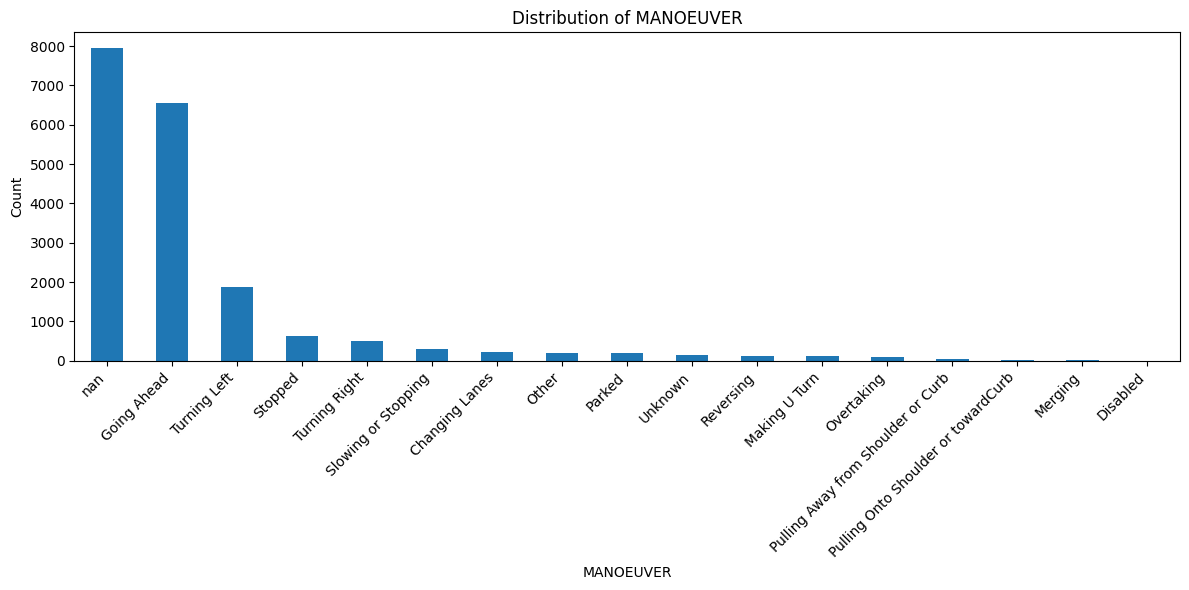


7. Crosstab with ACCLASS
ACCLASS                              Fatal  Non-Fatal Injury  \
MANOEUVER                                                      
Changing Lanes                          25               201   
Disabled                                 0                 4   
Going Ahead                            951              5582   
Making U Turn                            7               105   
Merging                                  2                17   
Other                                   15               171   
Overtaking                               8                88   
Parked                                  37               148   
Pulling Away from Shoulder or Curb       6                36   
Pulling Onto Shoulder or towardCurb      1                20   
Reversing                               22               101   
Slowing or Stopping                     16               278   
Stopped                                 45               589   
Turning Left  

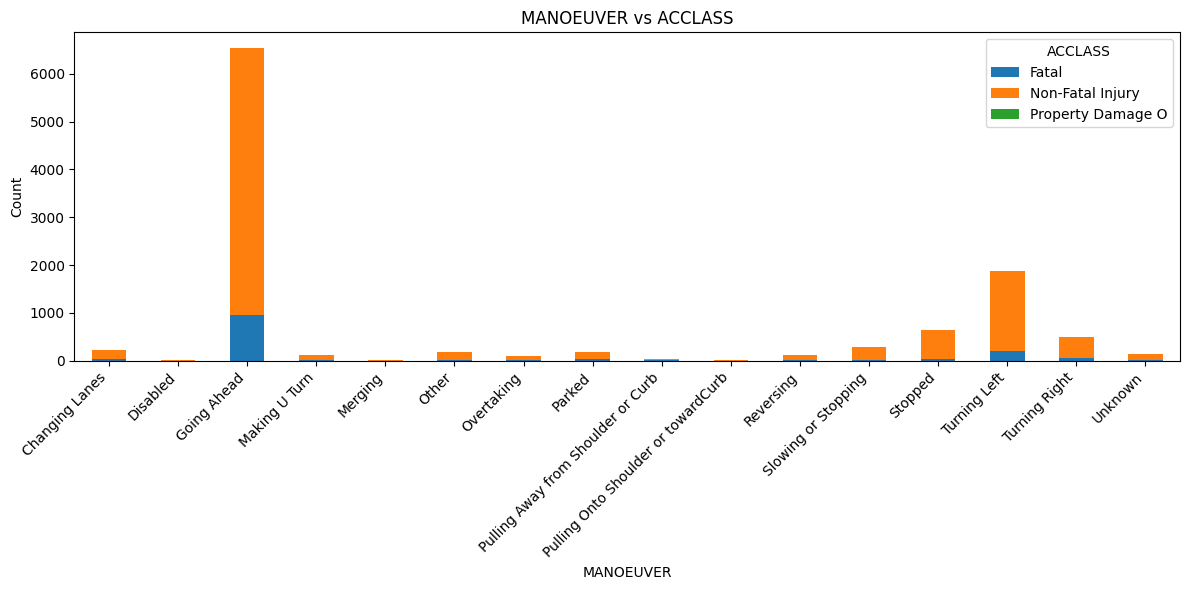

In [34]:
# ============================================================
# FEATURE: MANOEUVER
# Description: Vehicle Manoeuvre
# ============================================================

feature = "MANOEUVER"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


FEATURE: DRIVACT

1. Data Type
object

2. Missing Values
Missing: 9289
Missing %: 49.0

3. Number of Unique Values
13

4. Unique Values
['Driving Properly' 'Lost control' 'Improper Lane Change'
 'Disobeyed Traffic Control' 'Failed to Yield Right of Way' 'Other'
 'Speed too Fast For Condition' 'Exceeding Speed Limit' 'Improper Turn'
 'Following too Close' 'Improper Passing' 'Wrong Way on One Way Road'
 'Speed too Slow']

5. Frequency Distribution
DRIVACT
NaN                             9289
Driving Properly                4425
Failed to Yield Right of Way    1603
Lost control                    1007
Improper Turn                    614
Other                            529
Disobeyed Traffic Control        497
Exceeding Speed Limit            264
Following too Close              254
Speed too Fast For Condition     216
Improper Lane Change             125
Improper Passing                 121
Wrong Way on One Way Road          9
Speed too Slow                     4
Name: count, dtype: int

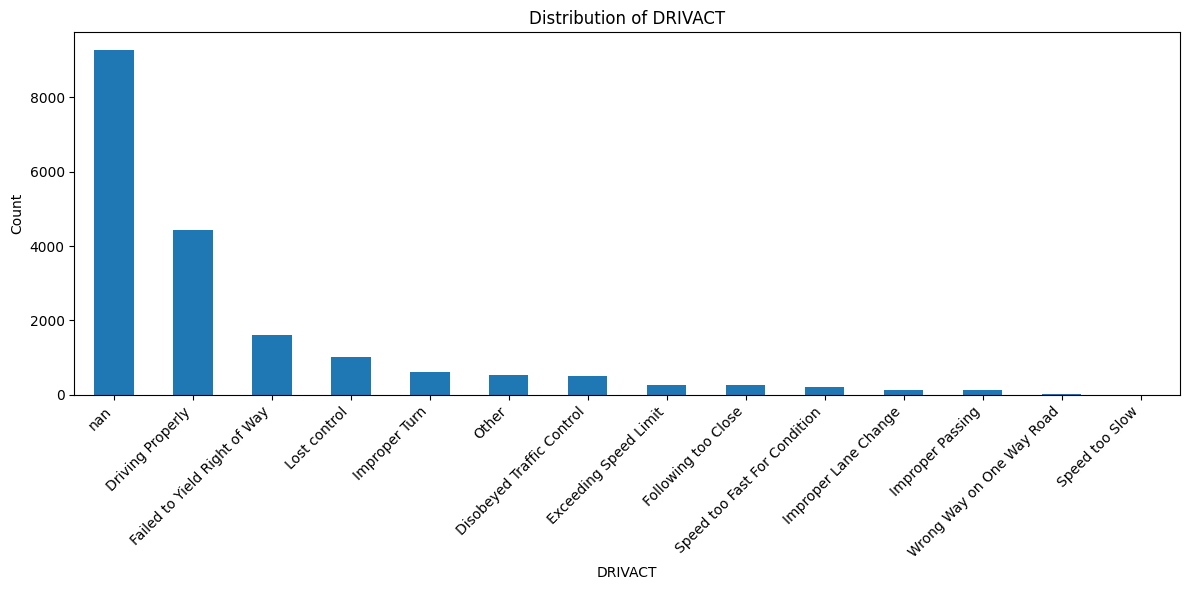


7. Crosstab with ACCLASS
ACCLASS                       Fatal  Non-Fatal Injury  Property Damage O
DRIVACT                                                                 
Disobeyed Traffic Control        63               434                  0
Driving Properly                598              3820                  7
Exceeding Speed Limit            84               179                  0
Failed to Yield Right of Way    179              1423                  1
Following too Close               4               250                  0
Improper Lane Change             11               114                  0
Improper Passing                 12               109                  0
Improper Turn                    57               557                  0
Lost control                    180               826                  1
Other                            74               455                  0
Speed too Fast For Condition     26               189                  1
Speed too Slow           

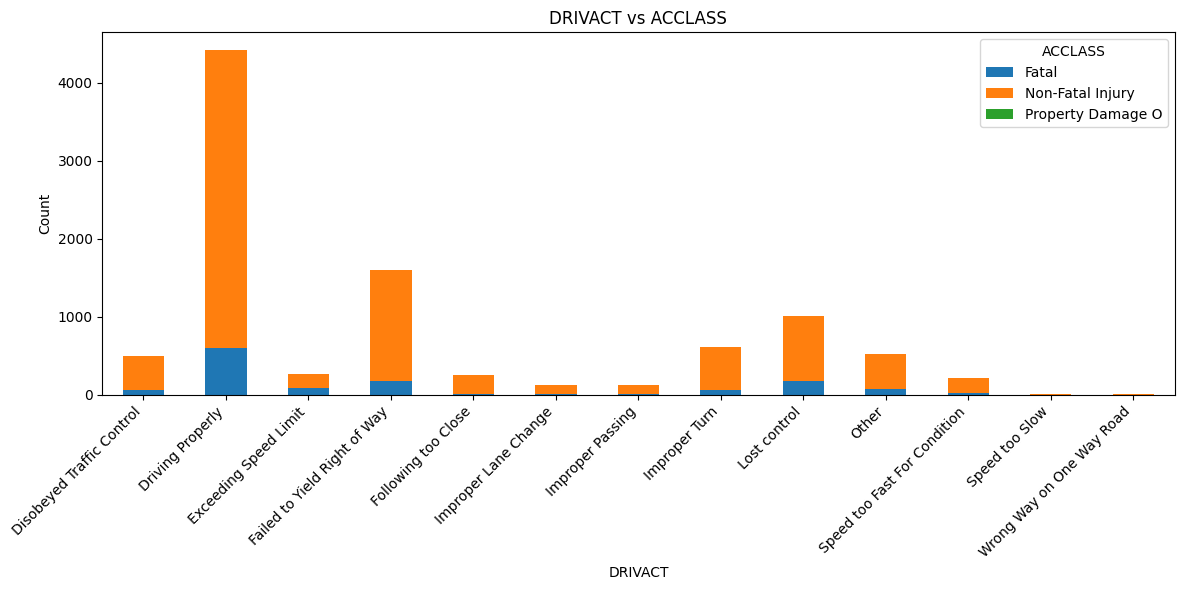

In [35]:
# ============================================================
# FEATURE: DRIVACT
# Description: Driver Action
# ============================================================

feature = "DRIVACT"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



FEATURE: DRIVCOND

1. Data Type
object

2. Missing Values
Missing: 9291
Missing %: 49.01

3. Number of Unique Values
10

4. Unique Values
['Normal' 'Ability Impaired, Alcohol Over .08' 'Inattentive' 'Unknown'
 'Medical or Physical Disability' 'Had Been Drinking' 'Fatigue' 'Other'
 'Ability Impaired, Alcohol' 'Ability Impaired, Drugs']

5. Frequency Distribution
DRIVCOND
NaN                                   9291
Normal                                6158
Inattentive                           1603
Unknown                               1129
Medical or Physical Disability         181
Had Been Drinking                      166
Ability Impaired, Alcohol Over .08     132
Ability Impaired, Alcohol              122
Other                                   97
Fatigue                                 58
Ability Impaired, Drugs                 20
Name: count, dtype: int64

6. Percentage Distribution
DRIVCOND
NaN                                   49.01
Normal                                32.48
In

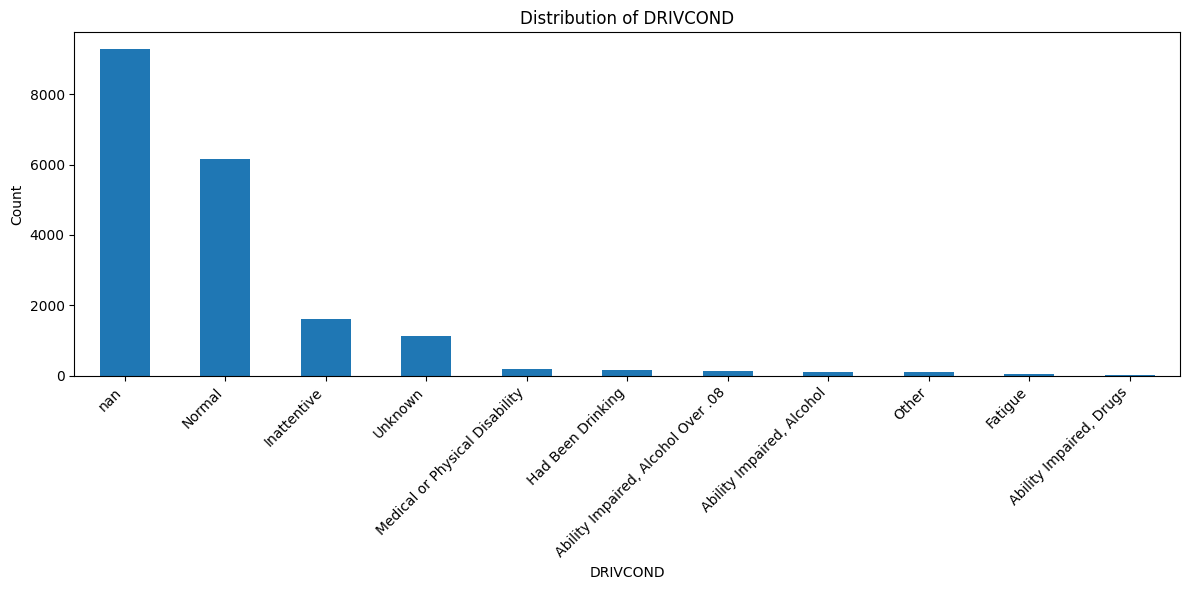


7. Crosstab with ACCLASS
ACCLASS                             Fatal  Non-Fatal Injury  Property Damage O
DRIVCOND                                                                      
Ability Impaired, Alcohol              18               104                  0
Ability Impaired, Alcohol Over .08     24               108                  0
Ability Impaired, Drugs                 8                12                  0
Fatigue                                 4                54                  0
Had Been Drinking                      33               133                  0
Inattentive                           177              1425                  1
Medical or Physical Disability         19               161                  0
Normal                                685              5466                  7
Other                                  16                81                  0
Unknown                               303               824                  2

8. Percentage Crosstab
AC

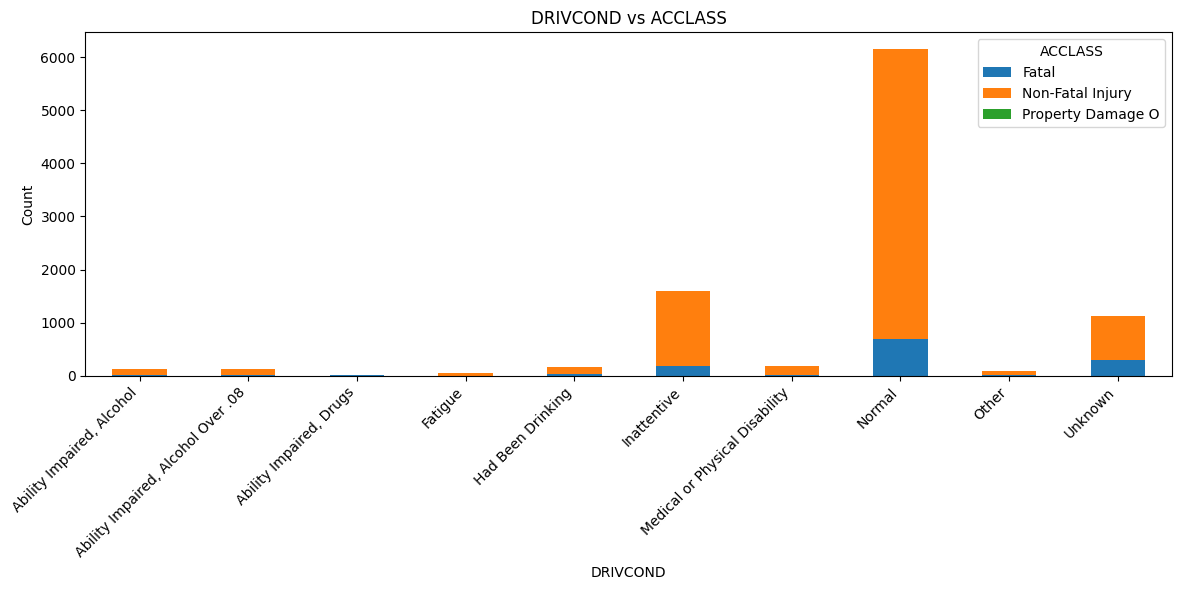

In [36]:
# ============================================================
# FEATURE: DRIVCOND
# Description: Driver Condition
# ============================================================

feature = "DRIVCOND"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


FEATURE: PEDTYPE

1. Data Type
object

2. Missing Values
Missing: 15728
Missing %: 82.97

3. Number of Unique Values
16

4. Unique Values
['Pedestrian hit at mid-block'
 'Vehicle is going straight thru inter.while ped cross without ROW'
 'Vehicle is going straight thru inter.while ped cross with ROW'
 'Pedestrian hit a PXO/ped. Mid-block signal'
 'Pedestrian involved in a collision with transit vehicle anywhere along roadway'
 'Vehicle turns left while ped crosses with ROW at inter.'
 'Other / Undefined'
 'Vehicle turns left while ped crosses without ROW at inter.'
 'Vehicle turns right while ped crosses with ROW at inter.'
 'Vehicle hits the pedestrian walking or running out from between parked vehicles at mid-block'
 'Unknown' 'Vehicle turns right while ped crosses without ROW at inter.'
 'Pedestrian hit on sidewalk or shoulder'
 'Vehicle is reversing and hits pedestrian'
 'Pedestrian hit at private driveway' 'Pedestrian hit at parking lot']

5. Frequency Distribution
PEDTYPE
NaN   

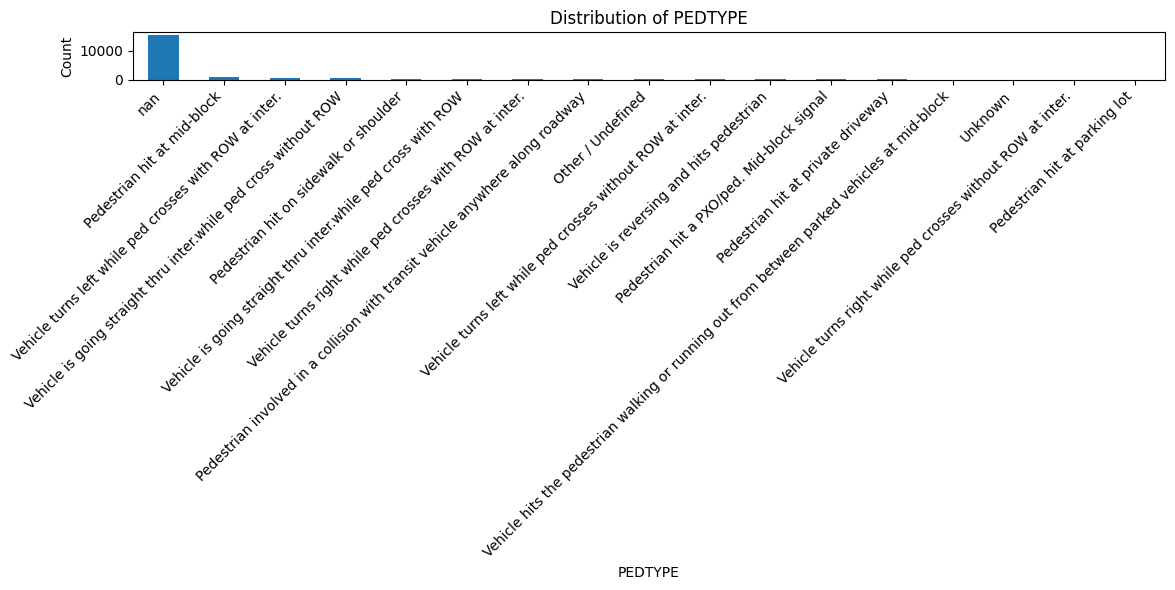


7. Crosstab with ACCLASS
ACCLASS                                             Fatal  Non-Fatal Injury  \
PEDTYPE                                                                       
Other / Undefined                                      13                78   
Pedestrian hit a PXO/ped. Mid-block signal             10                60   
Pedestrian hit at mid-block                           194               613   
Pedestrian hit at parking lot                           2                 1   
Pedestrian hit at private driveway                      7                35   
Pedestrian hit on sidewalk or shoulder                 63               194   
Pedestrian involved in a collision with transit...     36               113   
Unknown                                                 4                21   
Vehicle hits the pedestrian walking or running ...      3                25   
Vehicle is going straight thru inter.while ped ...     30               159   
Vehicle is going straight 

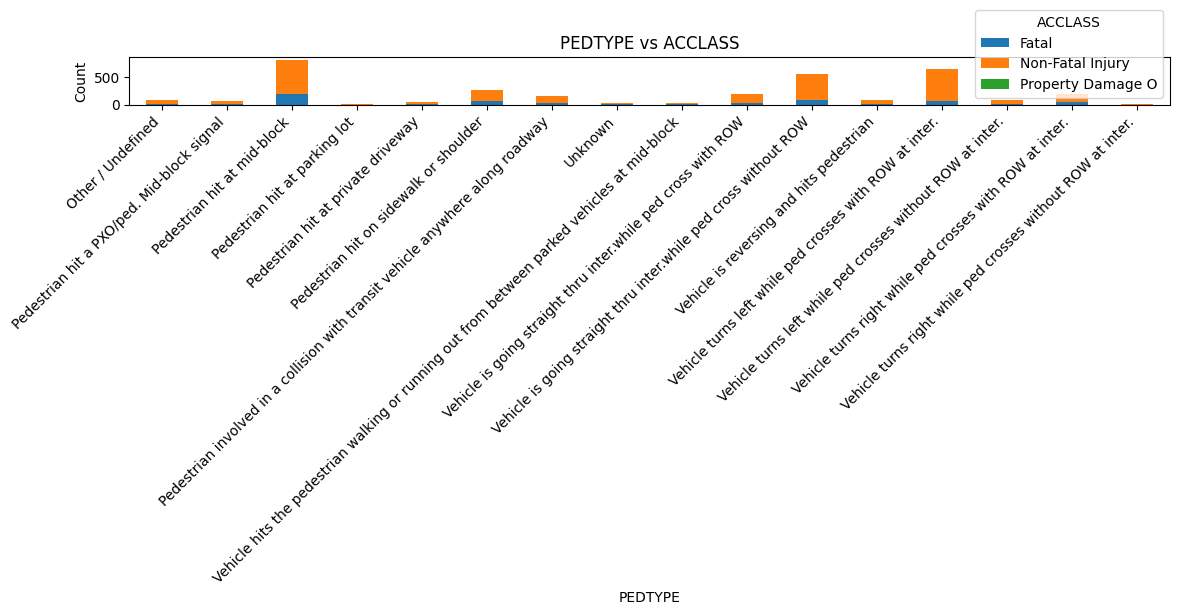

In [37]:

# ============================================================
# FEATURE: PEDTYPE
# Description: Pedestrian Type
# ============================================================

feature = "PEDTYPE"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



FEATURE: PEDACT

1. Data Type
object

2. Missing Values
Missing: 15730
Missing %: 82.98

3. Number of Unique Values
15

4. Unique Values
['Crossing without right of way' 'Crossing with right of way'
 'Crossing, Pedestrian Crossover' 'Crossing, no Traffic Control' 'Other'
 'Running onto Roadway' 'Coming From Behind Parked Vehicle'
 'Pushing/Working on Vehicle' 'On Sidewalk or Shoulder'
 'Walking on Roadway Against Traffic' 'Playing or Working on Highway'
 'Person Getting on/off Vehicle' 'Walking on Roadway with Traffic'
 'Crossing marked crosswalk without ROW'
 'Person Getting on/off School Bus']

5. Frequency Distribution
PEDACT
NaN                                      15730
Crossing with right of way                1019
Crossing, no Traffic Control               730
Crossing without right of way              453
On Sidewalk or Shoulder                    284
Other                                      240
Running onto Roadway                       235
Crossing, Pedestrian Crossover   

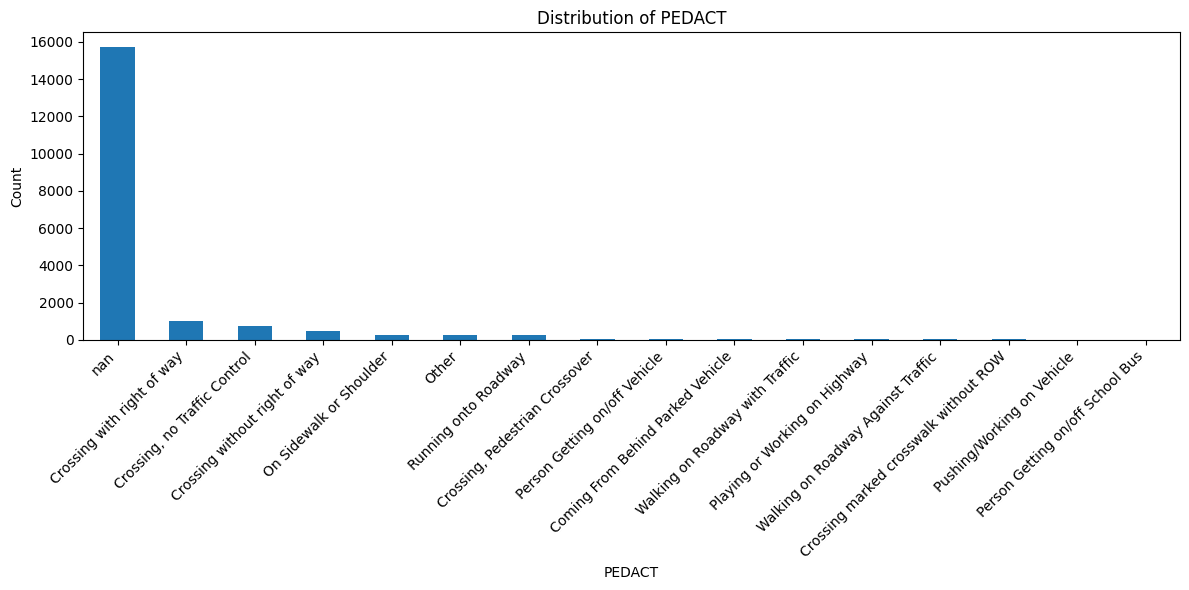


7. Crosstab with ACCLASS
ACCLASS                                Fatal  Non-Fatal Injury  \
PEDACT                                                           
Coming From Behind Parked Vehicle          7                30   
Crossing marked crosswalk without ROW      7                14   
Crossing with right of way               146               873   
Crossing without right of way             71               380   
Crossing, Pedestrian Crossover            10                58   
Crossing, no Traffic Control             194               535   
On Sidewalk or Shoulder                   70               214   
Other                                     43               197   
Person Getting on/off School Bus           0                 2   
Person Getting on/off Vehicle              5                34   
Playing or Working on Highway              4                22   
Pushing/Working on Vehicle                 3                13   
Running onto Roadway                      24      

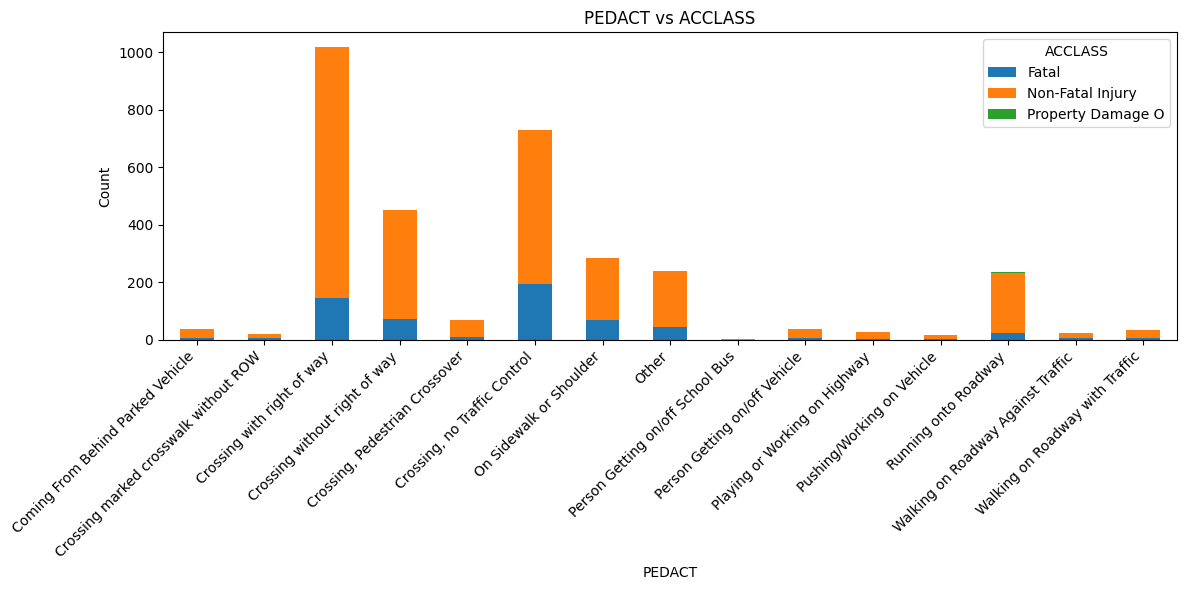

In [38]:
# ============================================================
# FEATURE: PEDACT
# Description: Pedestrian Action
# ============================================================

feature = "PEDACT"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



FEATURE: PEDCOND

1. Data Type
object

2. Missing Values
Missing: 15711
Missing %: 82.88

3. Number of Unique Values
10

4. Unique Values
['Inattentive' 'Normal' 'Unknown' 'Medical or Physical Disability'
 'Had Been Drinking' 'Ability Impaired, Alcohol' 'Other'
 'Ability Impaired, Alcohol Over .80' 'Ability Impaired, Drugs' 'Fatigue']

5. Frequency Distribution
PEDCOND
NaN                                   15711
Normal                                 1842
Inattentive                             560
Unknown                                 399
Had Been Drinking                       222
Other                                    84
Medical or Physical Disability           72
Ability Impaired, Alcohol                41
Ability Impaired, Alcohol Over .80       12
Ability Impaired, Drugs                  10
Fatigue                                   4
Name: count, dtype: int64

6. Percentage Distribution
PEDCOND
NaN                                   82.88
Normal                               

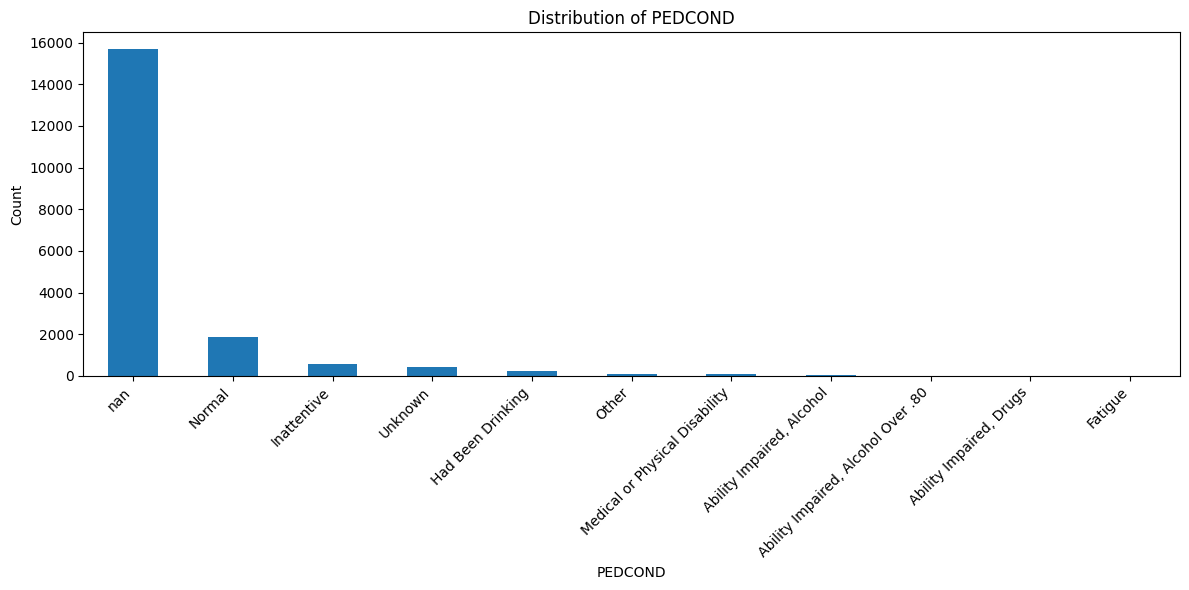


7. Crosstab with ACCLASS
ACCLASS                             Fatal  Non-Fatal Injury  Property Damage O
PEDCOND                                                                       
Ability Impaired, Alcohol               5                36                  0
Ability Impaired, Alcohol Over .80      1                11                  0
Ability Impaired, Drugs                 0                10                  0
Fatigue                                 2                 2                  0
Had Been Drinking                      26               196                  0
Inattentive                            94               466                  0
Medical or Physical Disability         20                52                  0
Normal                                253              1589                  0
Other                                  24                58                  2
Unknown                               169               228                  2

8. Percentage Crosstab
AC

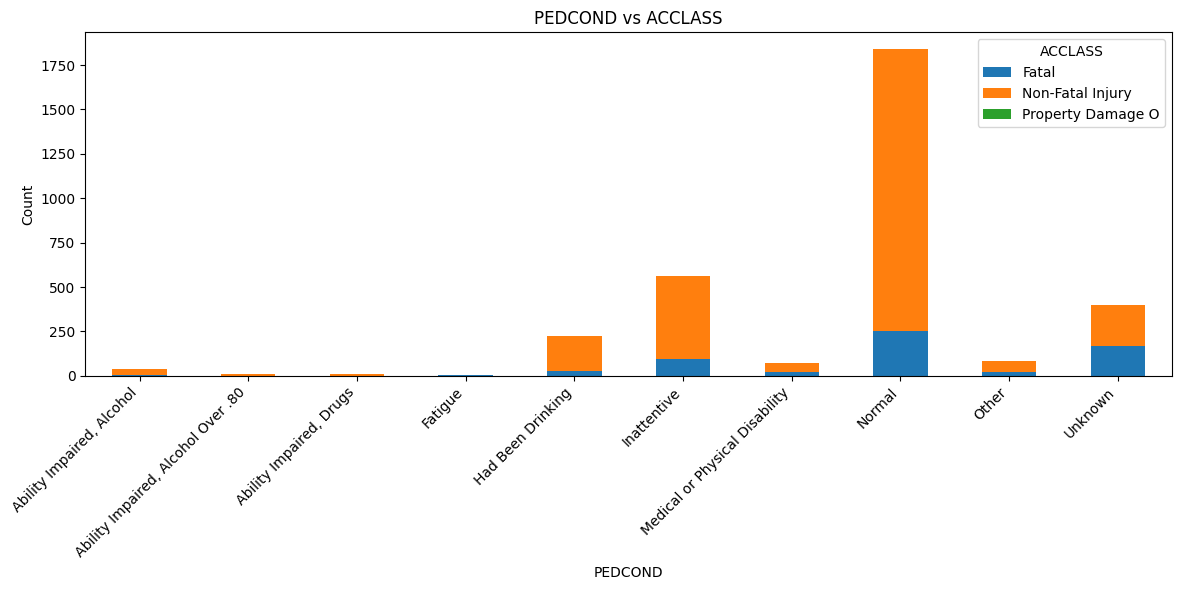

In [39]:
# ============================================================
# FEATURE: PEDCOND
# Description: Pedestrian Condition
# ============================================================

feature = "PEDCOND"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



FEATURE: CYCLISTYPE

1. Data Type
object

2. Missing Values
Missing: 18152
Missing %: 95.75

3. Number of Unique Values
22

4. Unique Values
['Motorist turned left across cyclists path.'
 'Motorist turning right on green or amber at signalized intersection strikes cyclist.'
 'Cyclist struck opened vehicle door'
 'Cyclist and Driver travelling in same direction. One vehicle rear-ended the other.'
 'Motorist turns right at non-signal Inter.(stop, yield, no cont.,and dwy) and strikes cyclist.'
 'Cyclist makes u-turn in-front of driver.'
 'Cyclist and Driver travelling in same direction. One vehicle sideswipes the other.'
 'Cyclist strikes pedestrian.'
 'Cyclist loses control and strikes object (pole, ttc track)'
 'Cyclist without ROW rides into path of motorist at inter, lnwy, dwy-Cyclist not turn.'
 'Cyclist turns right across motorists path'
 'Motorist turning right on red at signalized intersection strikes cyclist.'
 'Cyclist turned left across motorists path.'
 'Motorist without ROW 

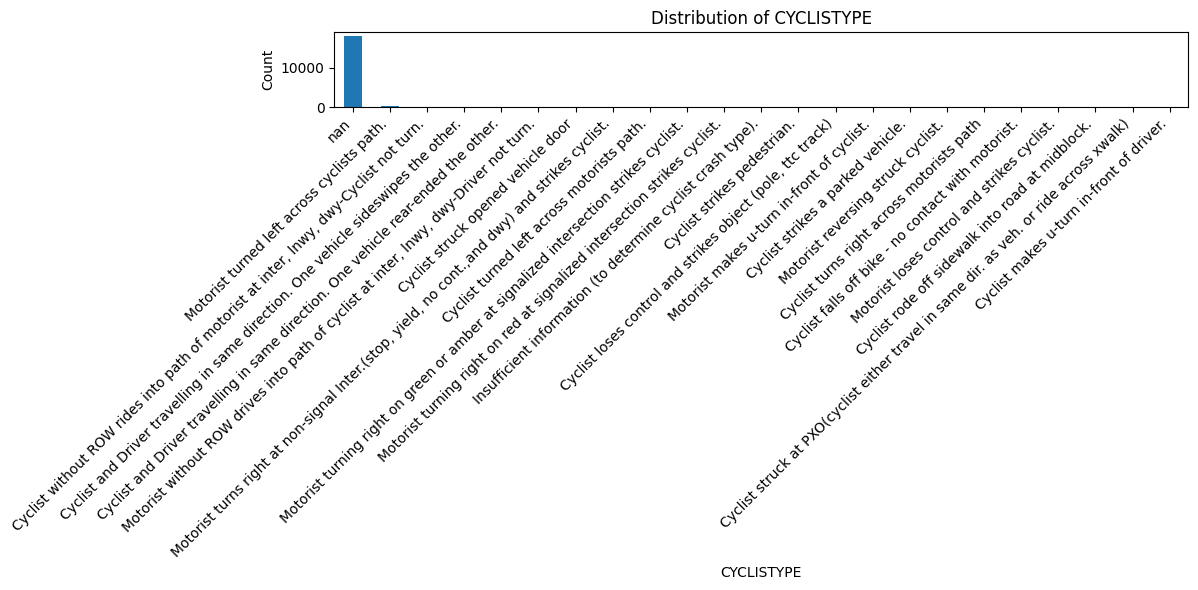


7. Crosstab with ACCLASS
ACCLASS                                             Fatal  Non-Fatal Injury
CYCLISTYPE                                                                 
Cyclist and Driver travelling in same direction...      3                56
Cyclist and Driver travelling in same direction...      5               109
Cyclist falls off bike - no contact with motorist.      0                 5
Cyclist loses control and strikes object (pole,...      1                13
Cyclist makes u-turn in-front of driver.                1                 1
Cyclist rode off sidewalk into road at midblock.        0                 4
Cyclist strikes a parked vehicle.                       2                 7
Cyclist strikes pedestrian.                             0                17
Cyclist struck at PXO(cyclist either travel in ...      1                 1
Cyclist struck opened vehicle door                      1                54
Cyclist turned left across motorists path.              3     

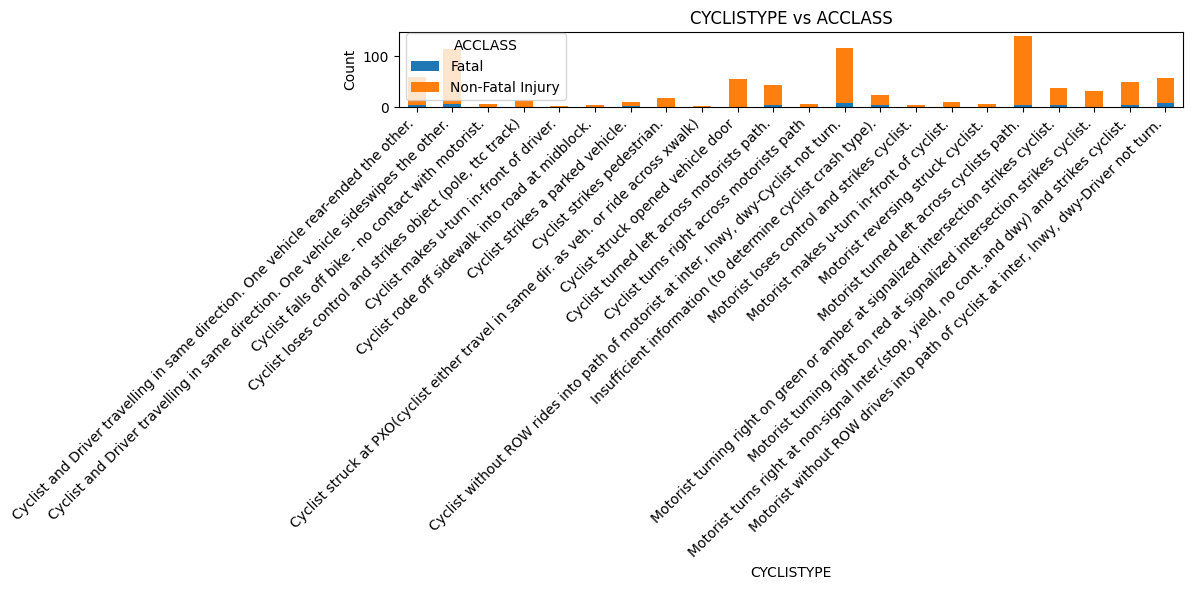

In [40]:
# ============================================================
# FEATURE: CYCLISTYPE
# Description: Cyclist Type
# ============================================================

feature = "CYCLISTYPE"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


FEATURE: CYCACT

1. Data Type
object

2. Missing Values
Missing: 18155
Missing %: 95.77

3. Number of Unique Values
11

4. Unique Values
['Driving Properly' 'Other' 'Improper Turn' 'Improper Passing'
 'Disobeyed Traffic Control' 'Lost control' 'Failed to Yield Right of Way'
 'Improper Lane Change' 'Following too Close'
 'Speed too Fast For Condition' 'Wrong Way on One Way Road']

5. Frequency Distribution
CYCACT
NaN                             18155
Driving Properly                  444
Disobeyed Traffic Control          85
Other                              79
Failed to Yield Right of Way       65
Lost control                       42
Improper Turn                      27
Improper Lane Change               22
Improper Passing                   20
Speed too Fast For Condition        9
Wrong Way on One Way Road           5
Following too Close                 4
Name: count, dtype: int64

6. Percentage Distribution
CYCACT
NaN                             95.77
Driving Properly            

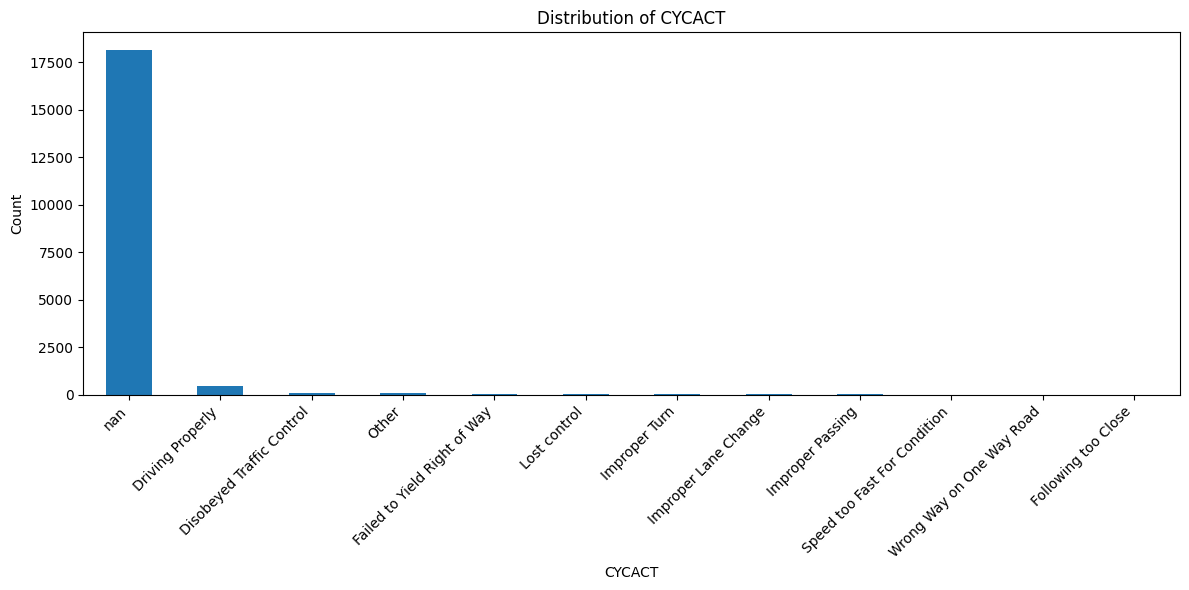


7. Crosstab with ACCLASS
ACCLASS                       Fatal  Non-Fatal Injury
CYCACT                                               
Disobeyed Traffic Control         7                78
Driving Properly                 22               422
Failed to Yield Right of Way      1                64
Following too Close               0                 4
Improper Lane Change              0                22
Improper Passing                  1                19
Improper Turn                     3                24
Lost control                      5                37
Other                             6                73
Speed too Fast For Condition      0                 9
Wrong Way on One Way Road         0                 5

8. Percentage Crosstab
ACCLASS                       Fatal  Non-Fatal Injury
CYCACT                                               
Disobeyed Traffic Control      8.24             91.76
Driving Properly               4.95             95.05
Failed to Yield Right of Way   1

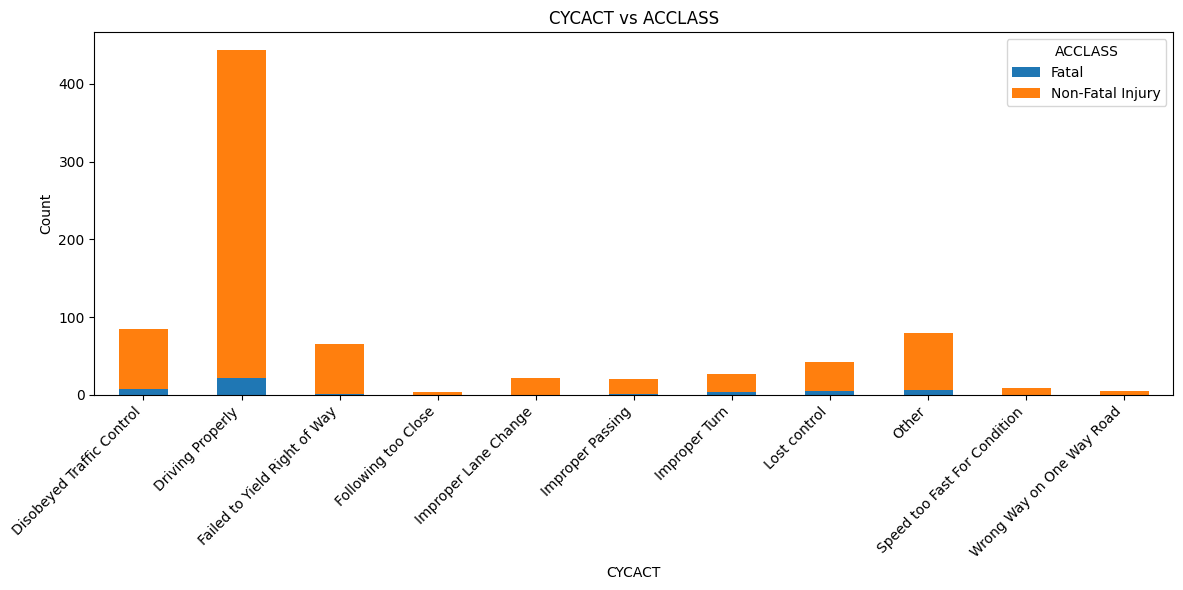

In [41]:
# ============================================================
# FEATURE: CYCACT
# Description: Cyclist Action
# ============================================================

feature = "CYCACT"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



FEATURE: CYCCOND

1. Data Type
object

2. Missing Values
Missing: 18157
Missing %: 95.78

3. Number of Unique Values
10

4. Unique Values
['Normal' 'Inattentive' 'Had Been Drinking' 'Unknown'
 'Ability Impaired, Drugs' 'Ability Impaired, Alcohol Over .80'
 'Medical or Physical Disability' 'Ability Impaired, Alcohol' 'Other'
 'Fatigue']

5. Frequency Distribution
CYCCOND
NaN                                   18157
Normal                                  557
Inattentive                             110
Unknown                                  79
Had Been Drinking                        30
Other                                    12
Ability Impaired, Alcohol                 4
Medical or Physical Disability            3
Ability Impaired, Drugs                   2
Fatigue                                   2
Ability Impaired, Alcohol Over .80        1
Name: count, dtype: int64

6. Percentage Distribution
CYCCOND
NaN                                   95.78
Normal                              

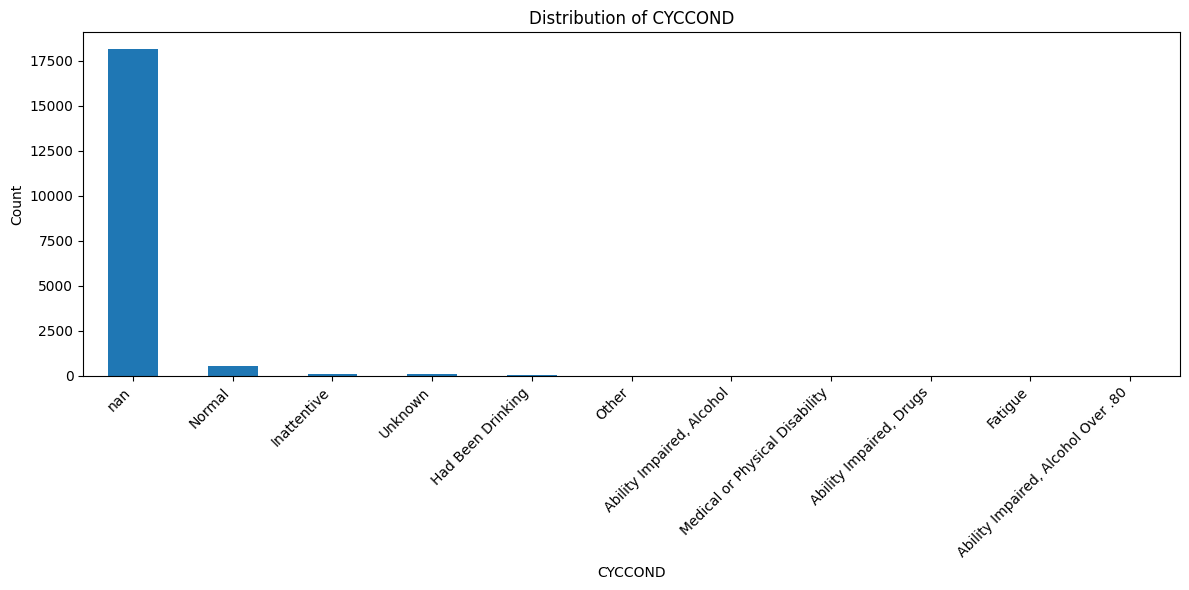


7. Crosstab with ACCLASS
ACCLASS                             Fatal  Non-Fatal Injury
CYCCOND                                                    
Ability Impaired, Alcohol               0                 4
Ability Impaired, Alcohol Over .80      0                 1
Ability Impaired, Drugs                 0                 2
Fatigue                                 0                 2
Had Been Drinking                       2                28
Inattentive                             1               109
Medical or Physical Disability          0                 3
Normal                                 24               533
Other                                   2                10
Unknown                                16                63

8. Percentage Crosstab
ACCLASS                             Fatal  Non-Fatal Injury
CYCCOND                                                    
Ability Impaired, Alcohol            0.00            100.00
Ability Impaired, Alcohol Over .80   0.00         

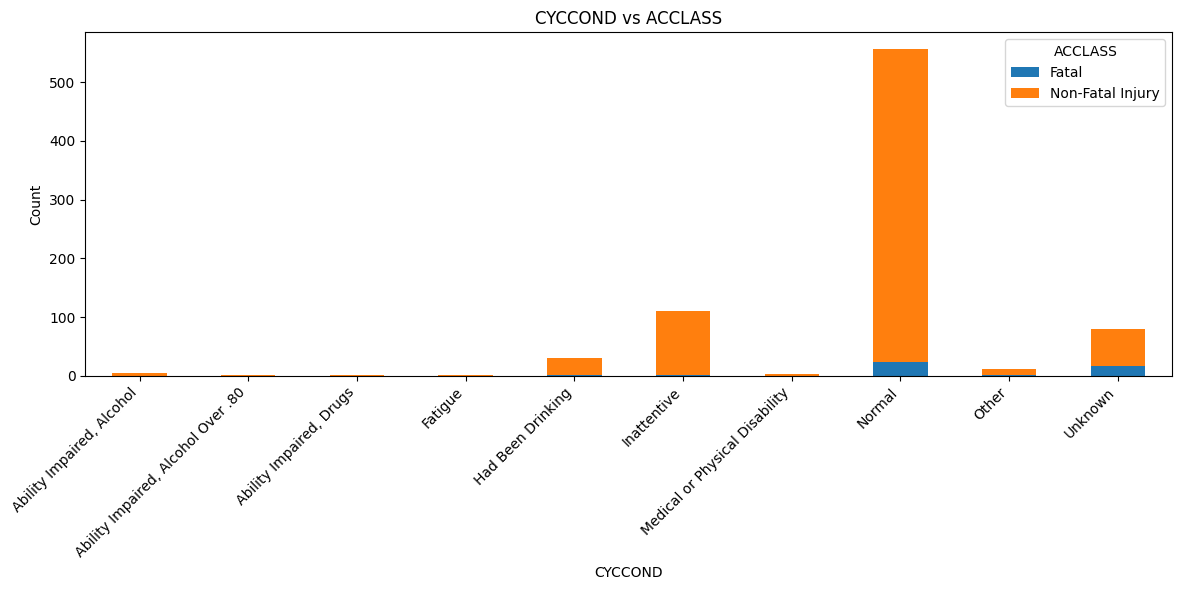

In [42]:
# ============================================================
# FEATURE: CYCCOND
# Description: Cyclist Condition
# ============================================================

feature = "CYCCOND"

print("\n" + "="*80)
print("FEATURE:", feature)
print("="*80)

print("\n1. Data Type")
print(df[feature].dtype)

print("\n2. Missing Values")
missing = df[feature].isnull().sum()
print("Missing:", missing)
print("Missing %:", round(missing/len(df)*100,2))

print("\n3. Number of Unique Values")
print(df[feature].nunique())

print("\n4. Unique Values")
print(df[feature].dropna().unique())

print("\n5. Frequency Distribution")
print(df[feature].value_counts(dropna=False))

print("\n6. Percentage Distribution")
print((df[feature].value_counts(normalize=True, dropna=False)*100).round(2))

plt.figure(figsize=(12,6))
df[feature].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n7. Crosstab with ACCLASS")
ct = pd.crosstab(df[feature], df["ACCLASS"])
print(ct)

print("\n8. Percentage Crosstab")
pct = (pd.crosstab(df[feature], df["ACCLASS"], normalize="index")*100).round(2)
print(pct)

ct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title(f"{feature} vs ACCLASS")
plt.xlabel(feature)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()